<a href="https://colab.research.google.com/github/saatour/GW170817/blob/main/10082026_Contour_with_secondary_island_CARD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1 — Repair / standardise the Colab Python environment
# ============================================================

%pip install -q --upgrade \
    "matplotlib>=3.10" \
    "healpy>=1.19" \
    "astropy>=7.0" \
    "pyvo>=1.6" \
    "pandas>=2.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 26.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.


In [2]:
%pip install -q "pandas==2.2.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 76.7 MB/s eta 0:00:00


In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import healpy as hp
import astropy
import pyvo

print("NumPy:     ", np.__version__)
print("pandas:    ", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("healpy:    ", hp.__version__)
print("Astropy:   ", astropy.__version__)
print("PyVO:      ", pyvo.__version__)

print("\nAll imports successful.")

NumPy:      2.0.2
pandas:     2.2.2
Matplotlib: 3.11.1
healpy:     1.20.0
Astropy:    8.0.1
PyVO:       1.9.1

All imports successful.


In [2]:
# ============================================================
# CELL 2 — Imports and analysis configuration
# GW190814: complete 90% credible-region galaxy catalogue
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import healpy as hp

from astropy.io import fits
from astropy import units as u
from astropy.cosmology import Planck18 as cosmo

from pyvo import dal as vo


# ------------------------------------------------------------
# Event / sky-map configuration
# ------------------------------------------------------------

EVENT = "GW190814"

# Public released GW190814 sky map
SKYMAP_URL = (
    "https://dcc.ligo.org/LIGO-P2000230/public/"
    "GW190814_skymap.fits.gz"
)

# Scientific credible region
CREDIBLE_LEVEL = 0.90


# ------------------------------------------------------------
# DES catalogue configuration
# ------------------------------------------------------------

TAP_URL = "https://datalab.noirlab.edu/tap"

# Retain the same basic catalogue limits as the old workflow
SQL_FATAL_QUALITY = True
MAG_MIN = 16.0
MAG_MAX = 24.5


# ------------------------------------------------------------
# Redshift selection
# ------------------------------------------------------------

# Legacy global redshift interval used in the existing analysis.
#
# IMPORTANT:
# We retain this for the first rebuild so that the principal
# methodological change is ONLY:
#
#   old: main island / bounding rectangle
#   new: complete native 90% GW credible region
#
# Once that catalogue is reproduced successfully, we can replace
# this blunt global interval with the pixel-dependent 3D distance
# posterior (DISTMU, DISTSIGMA, DISTNORM).
Z_MIN = 0.043
Z_MAX = 0.061


# ------------------------------------------------------------
# Output configuration
# ------------------------------------------------------------

OUTPUT_DIR = Path("GW190814_full_90pct")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# NOIRLab TAP connection
# ------------------------------------------------------------

tap_service = vo.TAPService(TAP_URL)


# ------------------------------------------------------------
# Configuration summary
# ------------------------------------------------------------

print(f"Event:                 {EVENT}")
print(f"Credible level:        {CREDIBLE_LEVEL:.0%}")
print(f"Magnitude range:        {MAG_MIN:.1f} < i < {MAG_MAX:.1f}")
print(f"Legacy redshift range:  {Z_MIN:.3f} < z < {Z_MAX:.3f}")
print(f"Output directory:       {OUTPUT_DIR.resolve()}")
print()
print("Configuration complete.")

Event:                 GW190814
Credible level:        90%
Magnitude range:        16.0 < i < 24.5
Legacy redshift range:  0.043 < z < 0.061
Output directory:       /content/GW190814_full_90pct

Configuration complete.


In [4]:
# ============================================================
# CELL 3 — Load and inspect the released GW190814 sky map
# Preserve the native HEALPix ordering
# ============================================================

from urllib.request import urlretrieve


# ------------------------------------------------------------
# Download sky map locally
# ------------------------------------------------------------

SKYMAP_PATH = OUTPUT_DIR / "GW190814_skymap.fits.gz"

if not SKYMAP_PATH.exists():
    print("Downloading released GW190814 sky map...")
    urlretrieve(SKYMAP_URL, SKYMAP_PATH)
else:
    print("Using existing local sky map.")

print(f"Sky map: {SKYMAP_PATH}")


# ------------------------------------------------------------
# Inspect FITS structure and header
# ------------------------------------------------------------

with fits.open(SKYMAP_PATH) as hdul:
    print("\nFITS structure:")
    hdul.info()

    header = hdul[1].header
    data = hdul[1].data

    print("\nAvailable columns:")
    print(data.columns.names)

    ordering = header.get("ORDERING", "UNKNOWN")
    coordsys = header.get(
        "COORDSYS",
        header.get("COORD", "UNKNOWN")
    )


# ------------------------------------------------------------
# Determine native HEALPix ordering
# ------------------------------------------------------------

if ordering.upper().startswith("NEST"):
    NESTED = True
elif ordering.upper().startswith("RING"):
    NESTED = False
else:
    raise ValueError(
        f"Unrecognised HEALPix ORDERING value: {ordering}"
    )


# ------------------------------------------------------------
# Read map layers while PRESERVING that ordering
# ------------------------------------------------------------

prob, distmu, distsigma, distnorm = hp.read_map(
    SKYMAP_PATH,
    field=(0, 1, 2, 3),
    dtype=np.float64,
    nest=NESTED
)


# ------------------------------------------------------------
# Infer HEALPix geometry
# ------------------------------------------------------------

npix = len(prob)
nside = hp.npix2nside(npix)


# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

prob_sum = np.sum(prob)
finite_prob = np.isfinite(prob)

print("\n--- HEALPix map summary ---")
print(f"NPIX:              {npix:,}")
print(f"NSIDE:             {nside}")
print(f"FITS ORDERING:     {ordering}")
print(f"Working ordering:  {'NESTED' if NESTED else 'RING'}")
print(f"Coordinate system: {coordsys}")
print(f"Probability sum:   {prob_sum:.12f}")
print(f"Finite PROB:       {finite_prob.sum():,} / {npix:,}")

print("\n--- 3D distance layers ---")
print(
    f"DISTMU:     finite={np.isfinite(distmu).sum():,}, "
    f"range={np.nanmin(distmu):.3f} to {np.nanmax(distmu):.3f}"
)
print(
    f"DISTSIGMA:  finite={np.isfinite(distsigma).sum():,}, "
    f"range={np.nanmin(distsigma):.3f} to {np.nanmax(distsigma):.3f}"
)
print(
    f"DISTNORM:   finite={np.isfinite(distnorm).sum():,}, "
    f"range={np.nanmin(distnorm):.6g} to {np.nanmax(distnorm):.6g}"
)


# ------------------------------------------------------------
# Hard sanity checks
# ------------------------------------------------------------

assert np.isclose(prob_sum, 1.0, atol=1e-6), \
    f"Probability map does not sum to 1: {prob_sum}"

assert hp.isnpixok(npix), \
    f"{npix} is not a valid HEALPix pixel count."

assert len(distmu) == npix
assert len(distsigma) == npix
assert len(distnorm) == npix

print("\nSky map loaded successfully in native ordering.")

Using existing local sky map.
Sky map: GW190814_full_90pct/GW190814_skymap.fits.gz

FITS structure:
Filename: GW190814_full_90pct/GW190814_skymap.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     32   12582912R x 4C   [D, D, D, D]   

Available columns:
['PROB', 'DISTMU', 'DISTSIGMA', 'DISTNORM']

--- HEALPix map summary ---
NPIX:              12,582,912
NSIDE:             1024
FITS ORDERING:     NESTED
Working ordering:  NESTED
Coordinate system: C
Probability sum:   1.000000000000
Finite PROB:       12,582,912 / 12,582,912

--- 3D distance layers ---
DISTMU:     finite=10,289,152, range=-49.663 to inf
DISTSIGMA:  finite=12,582,912, range=0.461 to 77.961
DISTNORM:   finite=12,582,912, range=0 to 7.19718e+07

Sky map loaded successfully in native ordering.


In [5]:
# ============================================================
# CELL 4 — Construct the native 90% credible-region mask
# ============================================================

# ------------------------------------------------------------
# Rank pixels by posterior probability
# ------------------------------------------------------------

# Highest-probability pixel first
sort_idx = np.argsort(prob)[::-1]

# Cumulative posterior probability in that order
cum_prob = np.cumsum(prob[sort_idx])


# ------------------------------------------------------------
# Find the smallest set of pixels containing >= 90%
# ------------------------------------------------------------

# Index of the first ranked pixel that takes us to/past 90%
cut_idx = np.searchsorted(
    cum_prob,
    CREDIBLE_LEVEL,
    side="left"
)

# Include that threshold-crossing pixel
credible_pixels = sort_idx[:cut_idx + 1]


# ------------------------------------------------------------
# Build scientific membership mask
# ------------------------------------------------------------

mask90 = np.zeros(npix, dtype=bool)
mask90[credible_pixels] = True


# ------------------------------------------------------------
# Build a credible-level field for later diagnostics/plotting
# ------------------------------------------------------------

credible_level_map = np.empty(npix, dtype=np.float64)
credible_level_map[sort_idx] = cum_prob


# ------------------------------------------------------------
# Quantify the resulting region
# ------------------------------------------------------------

n_pix_90 = mask90.sum()
prob_mass_90 = prob[mask90].sum()

pixel_area_deg2 = hp.nside2pixarea(
    nside,
    degrees=True
)

area_90_deg2 = n_pix_90 * pixel_area_deg2

threshold_prob = prob[sort_idx[cut_idx]]


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("--- Native 90% credible region ---")
print(f"Pixels included:       {n_pix_90:,}")
print(f"Pixel area:            {pixel_area_deg2:.8f} deg²")
print(f"Total sky area:        {area_90_deg2:.4f} deg²")
print(f"Posterior enclosed:    {prob_mass_90:.12f}")
print(f"Boundary pixel PROB:   {threshold_prob:.6e}")

print()
print("Scientific mask created as: mask90")
print("No smoothing applied.")
print("No island removed.")
print("No rectangular approximation used.")


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert prob_mass_90 >= CREDIBLE_LEVEL, \
    "90% mask contains less than the requested posterior mass."

# Removing the final included pixel should leave us below 90%.
prob_without_last = prob_mass_90 - threshold_prob

assert prob_without_last < CREDIBLE_LEVEL, \
    "Mask is not the minimum ranked-pixel set reaching 90%."

print("\n90% credible-region construction passed sanity checks.")

--- Native 90% credible region ---
Pixels included:       5,642
Pixel area:            0.00327849 deg²
Total sky area:        18.4972 deg²
Posterior enclosed:    0.900000333917
Boundary pixel PROB:   2.837380e-05

Scientific mask created as: mask90
No smoothing applied.
No island removed.
No rectangular approximation used.

90% credible-region construction passed sanity checks.


In [6]:
# ============================================================
# CELL 5 — Identify connected components ("islands")
# within the native 90% credible region
# ============================================================

from collections import deque


# ------------------------------------------------------------
# Find connected components using HEALPix neighbours
# ------------------------------------------------------------

unvisited = set(np.flatnonzero(mask90))
components = []

while unvisited:

    # Start a new component
    start = unvisited.pop()
    queue = deque([start])
    component = [start]

    while queue:
        pix = queue.popleft()

        neighbours = hp.get_all_neighbours(
            nside,
            pix,
            nest=NESTED
        )

        # healpy uses -1 where a neighbour does not exist
        for neighbour in neighbours:
            neighbour = int(neighbour)

            if neighbour >= 0 and neighbour in unvisited:
                unvisited.remove(neighbour)
                queue.append(neighbour)
                component.append(neighbour)

    components.append(np.asarray(component, dtype=np.int64))


# ------------------------------------------------------------
# Measure each component
# ------------------------------------------------------------

component_rows = []

for original_id, pixels in enumerate(components, start=1):

    mass = prob[pixels].sum()
    area = len(pixels) * pixel_area_deg2

    # Coordinates of pixel centres
    ra, dec = hp.pix2ang(
        nside,
        pixels,
        nest=NESTED,
        lonlat=True
    )

    # Posterior-weighted spherical centroid
    theta = np.radians(90.0 - dec)
    phi = np.radians(ra)

    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)

    weights = prob[pixels]

    x_c = np.average(x, weights=weights)
    y_c = np.average(y, weights=weights)
    z_c = np.average(z, weights=weights)

    r = np.sqrt(x_c**2 + y_c**2 + z_c**2)
    x_c /= r
    y_c /= r
    z_c /= r

    centroid_ra = np.degrees(np.arctan2(y_c, x_c)) % 360.0
    centroid_dec = np.degrees(np.arcsin(z_c))

    # Highest-posterior pixel in the component
    peak_pixel = pixels[np.argmax(prob[pixels])]

    peak_ra, peak_dec = hp.pix2ang(
        nside,
        peak_pixel,
        nest=NESTED,
        lonlat=True
    )

    component_rows.append({
        "original_component": original_id,
        "n_pixels": len(pixels),
        "posterior_mass": mass,
        "area_deg2": area,
        "centroid_ra_deg": centroid_ra,
        "centroid_dec_deg": centroid_dec,
        "peak_ra_deg": peak_ra,
        "peak_dec_deg": peak_dec,
        "ra_min_center_deg": np.min(ra),
        "ra_max_center_deg": np.max(ra),
        "dec_min_center_deg": np.min(dec),
        "dec_max_center_deg": np.max(dec),
    })


components_df = pd.DataFrame(component_rows)


# ------------------------------------------------------------
# Rank components by posterior mass
# Island 1 = largest posterior component
# ------------------------------------------------------------

components_df = (
    components_df
    .sort_values("posterior_mass", ascending=False)
    .reset_index(drop=True)
)

components_df.insert(
    0,
    "island_id",
    np.arange(1, len(components_df) + 1)
)


# ------------------------------------------------------------
# Create pixel -> island metadata map
#
# 0 = outside the 90% region
# 1, 2, ... = island ranked by posterior mass
# ------------------------------------------------------------

island_id_map = np.zeros(npix, dtype=np.int16)

for _, row in components_df.iterrows():

    island_id = int(row["island_id"])
    original_component = int(row["original_component"])

    pixels = components[original_component - 1]

    island_id_map[pixels] = island_id


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print(f"Connected components found: {len(components_df)}")
print()

display(
    components_df[
        [
            "island_id",
            "n_pixels",
            "posterior_mass",
            "area_deg2",
            "centroid_ra_deg",
            "centroid_dec_deg",
            "peak_ra_deg",
            "peak_dec_deg",
        ]
    ].style.format({
        "posterior_mass": "{:.6f}",
        "area_deg2": "{:.4f}",
        "centroid_ra_deg": "{:.4f}",
        "centroid_dec_deg": "{:.4f}",
        "peak_ra_deg": "{:.4f}",
        "peak_dec_deg": "{:.4f}",
    })
)


print(
    "\nTotal component probability:",
    f"{components_df['posterior_mass'].sum():.12f}"
)

print(
    "Total component area:",
    f"{components_df['area_deg2'].sum():.4f} deg²"
)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert np.isclose(
    components_df["posterior_mass"].sum(),
    prob_mass_90,
    atol=1e-12
)

assert components_df["n_pixels"].sum() == n_pix_90

assert np.all(island_id_map[mask90] > 0)
assert np.all(island_id_map[~mask90] == 0)

print("\nAll 90% pixels assigned to an island successfully.")

Connected components found: 2



,island_id,n_pixels,posterior_mass,area_deg2,centroid_ra_deg,centroid_dec_deg,peak_ra_deg,peak_dec_deg
0,1,4212,0.824697,13.8090,12.5775,-24.8861,12.6562,-24.8297
1,2,1430,0.075303,4.6882,22.1582,-32.1860,21.9727,-32.0459



Total component probability: 0.900000333917
Total component area: 18.4972 deg²

All 90% pixels assigned to an island successfully.


In [7]:
# ============================================================
# CELL 6 — Build safe database-query rectangles
# around every 90% credible-region island
# ============================================================

QUERY_PAD_DEG = 0.02   # 1.2 arcmin harmless safety padding


# ------------------------------------------------------------
# Helper: find the minimum RA interval containing a set of
# coordinates, correctly handling possible wrap at RA = 0°
# ------------------------------------------------------------

def minimal_ra_interval(ra_deg):
    ra = np.mod(np.asarray(ra_deg, dtype=float), 360.0)
    ra_sorted = np.sort(ra)

    if len(ra_sorted) == 1:
        return ra_sorted[0], ra_sorted[0], False

    # Find largest empty gap around the circle.
    gaps = np.diff(
        np.concatenate([ra_sorted, [ra_sorted[0] + 360.0]])
    )

    gap_i = np.argmax(gaps)

    # The minimum containing interval is everything except
    # that largest empty gap.
    ra_min = ra_sorted[(gap_i + 1) % len(ra_sorted)]
    ra_max = ra_sorted[gap_i]

    wraps_zero = ra_min > ra_max

    return float(ra_min), float(ra_max), bool(wraps_zero)


# ------------------------------------------------------------
# Obtain the actual corner coordinates of every HEALPix pixel
# in each island
# ------------------------------------------------------------

query_box_rows = []

for _, row in components_df.iterrows():

    island_id = int(row["island_id"])
    original_component = int(row["original_component"])

    pixels = components[original_component - 1]

    corner_ra = []
    corner_dec = []

    for pix in pixels:

        # Four vertices of this HEALPix pixel
        xyz = hp.boundaries(
            nside,
            int(pix),
            step=1,
            nest=NESTED
        )

        # hp.boundaries gives shape (3, 4);
        # vec2ang wants vectors as (N, 3)
        ra_v, dec_v = hp.vec2ang(
            xyz.T,
            lonlat=True
        )

        corner_ra.extend(ra_v)
        corner_dec.extend(dec_v)

    corner_ra = np.asarray(corner_ra)
    corner_dec = np.asarray(corner_dec)


    # --------------------------------------------------------
    # Exact RA/Dec enclosing rectangle from pixel vertices
    # --------------------------------------------------------

    ra_min, ra_max, wraps_zero = minimal_ra_interval(corner_ra)

    dec_min = float(np.min(corner_dec))
    dec_max = float(np.max(corner_dec))


    # --------------------------------------------------------
    # Add a tiny query-only safety pad
    # --------------------------------------------------------

    dec_min = max(-90.0, dec_min - QUERY_PAD_DEG)
    dec_max = min( 90.0, dec_max + QUERY_PAD_DEG)

    if not wraps_zero:
        ra_min = max(0.0, ra_min - QUERY_PAD_DEG)
        ra_max = min(360.0, ra_max + QUERY_PAD_DEG)
    else:
        # Wrapped interval:
        # RA >= ra_min OR RA <= ra_max
        ra_min = (ra_min - QUERY_PAD_DEG) % 360.0
        ra_max = (ra_max + QUERY_PAD_DEG) % 360.0


    query_box_rows.append({
        "island_id": island_id,
        "ra_min_deg": ra_min,
        "ra_max_deg": ra_max,
        "dec_min_deg": dec_min,
        "dec_max_deg": dec_max,
        "ra_wraps_zero": wraps_zero,
        "posterior_mass": float(row["posterior_mass"]),
        "area_deg2": float(row["area_deg2"]),
    })


query_boxes = pd.DataFrame(query_box_rows)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("DES query rectangles derived from HEALPix pixel boundaries:")
print()

display(
    query_boxes.style.format({
        "ra_min_deg": "{:.6f}",
        "ra_max_deg": "{:.6f}",
        "dec_min_deg": "{:.6f}",
        "dec_max_deg": "{:.6f}",
        "posterior_mass": "{:.6f}",
        "area_deg2": "{:.4f}",
    })
)

print()
print("These rectangles are QUERY FUNNELS ONLY.")
print("Scientific membership will still be determined by mask90.")

DES query rectangles derived from HEALPix pixel boundaries:



,island_id,ra_min_deg,ra_max_deg,dec_min_deg,dec_max_deg,ra_wraps_zero,posterior_mass,area_deg2
0,1,10.175313,14.961406,-27.383584,-22.165358,False,0.824697,13.8090
1,2,20.546406,23.926250,-33.619578,-30.932209,False,0.075303,4.6882



These rectangles are QUERY FUNNELS ONLY.
Scientific membership will still be determined by mask90.


In [8]:
# ============================================================
# CELL 7 — Query DES DR2 + Y6 Gold for both island rectangles
#
# Query-stage cuts ONLY:
#   flags_i < 4
#   16 <= mag_auto_i <= 24.5
#
# NO morphology cut yet.
# NO redshift cut yet.
# NO GW-mask cut yet.
# ============================================================

MAXREC_PER_QUERY = 5_000_000


# ------------------------------------------------------------
# Helper: construct the ADQL sky clause
# ------------------------------------------------------------

def make_sky_clause(row):

    ra_min = float(row["ra_min_deg"])
    ra_max = float(row["ra_max_deg"])
    dec_min = float(row["dec_min_deg"])
    dec_max = float(row["dec_max_deg"])
    wraps = bool(row["ra_wraps_zero"])

    if wraps:
        ra_clause = (
            f"(g.ra >= {ra_min:.10f} OR "
            f"g.ra <= {ra_max:.10f})"
        )
    else:
        ra_clause = (
            f"(g.ra BETWEEN {ra_min:.10f} "
            f"AND {ra_max:.10f})"
        )

    dec_clause = (
        f"(g.dec BETWEEN {dec_min:.10f} "
        f"AND {dec_max:.10f})"
    )

    return f"({ra_clause}) AND ({dec_clause})"


# ------------------------------------------------------------
# Same fatal-quality query used in the old pipeline
# ------------------------------------------------------------

where_quality = "1=1"

if SQL_FATAL_QUALITY:
    where_quality = (
        f"(g.flags_i < 4) "
        f"AND (g.mag_auto_i BETWEEN {MAG_MIN} AND {MAG_MAX})"
    )


# ------------------------------------------------------------
# Query each island rectangle separately
# ------------------------------------------------------------

des_query_parts = []
query_counts = []

for _, box in query_boxes.iterrows():

    island_id = int(box["island_id"])
    where_sky = make_sky_clause(box)

    adql = f"""
    SELECT
        g.coadd_object_id AS coadd_object_id,
        g.ra,
        g.dec,
        g.mag_auto_i,
        g.flags_i,
        y.dnf_z,
        y.wavg_spread_model_z,
        y.wavg_spreaderr_model_z,
        y.spread_model_z,
        y.spreaderr_model_z
    FROM des_dr2.main AS g
    JOIN des_dr2.y6_gold AS y
        ON g.coadd_object_id = y.coadd_object_id
    WHERE
        {where_sky}
        AND {where_quality}
    """

    print("=" * 60)
    print(f"Querying rectangle for island {island_id}...")
    print(
        f"RA:  {box['ra_min_deg']:.6f} to "
        f"{box['ra_max_deg']:.6f} deg"
    )
    print(
        f"Dec: {box['dec_min_deg']:.6f} to "
        f"{box['dec_max_deg']:.6f} deg"
    )

    # Server-side asynchronous TAP job.
    # maxrec is explicit because these queries contain millions of rows.
    result = tap_service.run_async(
        adql,
        maxrec=MAXREC_PER_QUERY
    )

    tbl = result.to_table()
    df = tbl.to_pandas()

    # Record which QUERY rectangle produced the object.
    # This is not yet the scientific island assignment.
    df["query_box_island"] = island_id

    n_rows = len(df)

    print(f"Rows returned: {n_rows:,}")

    if n_rows >= MAXREC_PER_QUERY:
        raise RuntimeError(
            f"Island {island_id} query returned {n_rows:,} rows, "
            f"which reached MAXREC_PER_QUERY={MAXREC_PER_QUERY:,}. "
            "The result may be truncated."
        )

    des_query_parts.append(df)

    query_counts.append({
        "island_id": island_id,
        "rectangle_rows": n_rows
    })


# ------------------------------------------------------------
# Combine both rectangle pulls
# ------------------------------------------------------------

des_rectangles = pd.concat(
    des_query_parts,
    ignore_index=True
)

query_counts_df = pd.DataFrame(query_counts)


# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DES rectangle-query summary")
print("=" * 60)

display(query_counts_df)

print(
    f"\nCombined rows from both rectangles: "
    f"{len(des_rectangles):,}"
)


# ------------------------------------------------------------
# Check for unexpected duplicate object IDs
# ------------------------------------------------------------

n_duplicate_ids = int(
    des_rectangles["coadd_object_id"].duplicated().sum()
)

print(
    f"Duplicate coadd_object_id values: "
    f"{n_duplicate_ids:,}"
)

if n_duplicate_ids > 0:
    print(
        "WARNING: duplicate DES object IDs found. "
        "Do not remove them yet; we should inspect why."
    )
else:
    print("No duplicate DES object IDs detected.")


print("\nColumns:")
print(des_rectangles.columns.tolist())

Querying rectangle for island 1...
RA:  10.175313 to 14.961406 deg
Dec: -27.383584 to -22.165358 deg
Rows returned: 2,224,204
Querying rectangle for island 2...
RA:  20.546406 to 23.926250 deg
Dec: -33.619578 to -30.932209 deg
Rows returned: 725,665

DES rectangle-query summary


,island_id,rectangle_rows
0,1,2224204
1,2,725665



Combined rows from both rectangles: 2,949,869
Duplicate coadd_object_id values: 0
No duplicate DES object IDs detected.

Columns:
['coadd_object_id', 'ra', 'dec', 'mag_auto_i', 'flags_i', 'dnf_z', 'wavg_spread_model_z', 'wavg_spreaderr_model_z', 'spread_model_z', 'spreaderr_model_z', 'query_box_island']


In [9]:
# ============================================================
# CELL 8 — Apply the exact native 90% GW mask
# and assign each surviving DES object to its true island
# ============================================================


# ------------------------------------------------------------
# Convert every DES coordinate to its native HEALPix pixel
# ------------------------------------------------------------

ra_all = des_rectangles["ra"].to_numpy(dtype=float)
dec_all = des_rectangles["dec"].to_numpy(dtype=float)

des_pix = hp.ang2pix(
    nside,
    ra_all,
    dec_all,
    nest=NESTED,
    lonlat=True
)


# ------------------------------------------------------------
# Exact scientific membership test
# ------------------------------------------------------------

inside_90 = mask90[des_pix]


print("--- Exact GW 90% mask ---")
print(f"Objects in query rectangles: {len(des_rectangles):,}")
print(f"Objects inside native 90%:   {inside_90.sum():,}")
print(
    f"Objects rejected as box padding: "
    f"{(~inside_90).sum():,}"
)


# ------------------------------------------------------------
# Keep only objects actually inside the 90% credible region
# ------------------------------------------------------------

des_90 = des_rectangles.loc[inside_90].copy()

# Corresponding HEALPix pixels
des_90_pix = des_pix[inside_90]


# ------------------------------------------------------------
# Attach GW metadata to each DES object
# ------------------------------------------------------------

des_90["healpix_pixel"] = des_90_pix

des_90["island_id"] = island_id_map[des_90_pix]

des_90["gw_prob_pixel"] = prob[des_90_pix]

des_90["gw_credible_level"] = credible_level_map[des_90_pix]


# ------------------------------------------------------------
# Diagnostics by island
# ------------------------------------------------------------

mask_counts = (
    des_90
    .groupby("island_id")
    .size()
    .rename("objects_inside_90pct")
    .reset_index()
)

print("\nObjects inside the exact 90% region by island:")
display(mask_counts)


# ------------------------------------------------------------
# Verify that query-box identity and true GW-island identity
# agree for every surviving object
#
# They SHOULD, because the two boxes are widely separated.
# ------------------------------------------------------------

box_island_mismatch = (
    des_90["query_box_island"].astype(int)
    != des_90["island_id"].astype(int)
)

n_mismatch = int(box_island_mismatch.sum())

print(
    f"\nQuery-box / true-island mismatches: "
    f"{n_mismatch:,}"
)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert len(des_90) == inside_90.sum()

assert np.all(
    mask90[
        des_90["healpix_pixel"].to_numpy(dtype=int)
    ]
)

assert np.all(
    des_90["island_id"].to_numpy(dtype=int) > 0
)

assert set(
    des_90["island_id"].astype(int).unique()
).issubset(
    set(query_boxes["island_id"].astype(int))
)

assert n_mismatch == 0, \
    "Unexpected query-box / true-island mismatch detected."


print("\nExact native 90% filtering passed all sanity checks.")


# ------------------------------------------------------------
# Show useful columns
# ------------------------------------------------------------

print("\nColumns now available:")
print(des_90.columns.tolist())

--- Exact GW 90% mask ---
Objects in query rectangles: 2,949,869
Objects inside native 90%:   1,839,824
Objects rejected as box padding: 1,110,045

Objects inside the exact 90% region by island:


,island_id,objects_inside_90pct
0,1,1395164
1,2,444660



Query-box / true-island mismatches: 0

Exact native 90% filtering passed all sanity checks.

Columns now available:
['coadd_object_id', 'ra', 'dec', 'mag_auto_i', 'flags_i', 'dnf_z', 'wavg_spread_model_z', 'wavg_spreaderr_model_z', 'spread_model_z', 'spreaderr_model_z', 'query_box_island', 'healpix_pixel', 'island_id', 'gw_prob_pixel', 'gw_credible_level']


In [10]:
# ============================================================
# CELL 9 — Apply the original DES morphology cut
#
# Galaxy-like if:
#
#   spread_model_z + 3 * spreaderr_model_z > 0.005
#
# Prefer the weighted-average quantities when valid,
# exactly as in the original pipeline.
# ============================================================


# ------------------------------------------------------------
# Extract morphology quantities
# ------------------------------------------------------------

wavg_spread = des_90["wavg_spread_model_z"].to_numpy(dtype=float)
wavg_err    = des_90["wavg_spreaderr_model_z"].to_numpy(dtype=float)

spread      = des_90["spread_model_z"].to_numpy(dtype=float)
spread_err  = des_90["spreaderr_model_z"].to_numpy(dtype=float)


# ------------------------------------------------------------
# Determine whether weighted-average values are usable
#
# The DES missing-value sentinel used in the original notebook
# was approximately -99, so > -98 marks valid values.
# ------------------------------------------------------------

use_wavg = (
    (wavg_spread > -98)
    &
    (wavg_err > -98)
)


# ------------------------------------------------------------
# Construct the same morphology statistic as before
# ------------------------------------------------------------

morph_metric = np.where(
    use_wavg,
    wavg_spread + 3.0 * wavg_err,
    spread + 3.0 * spread_err
)


# ------------------------------------------------------------
# Apply galaxy / extended-source threshold
# ------------------------------------------------------------

galaxy_like = morph_metric > 0.005

des_galaxies = des_90.loc[galaxy_like].copy()


# ------------------------------------------------------------
# Preserve diagnostic metadata
# ------------------------------------------------------------

des_galaxies["morph_metric"] = morph_metric[galaxy_like]

des_galaxies["morph_source"] = np.where(
    use_wavg[galaxy_like],
    "wavg",
    "single"
)


# ------------------------------------------------------------
# Overall diagnostics
# ------------------------------------------------------------

print("--- DES morphology selection ---")
print(f"Objects before morphology: {len(des_90):,}")
print(f"Galaxy-like objects:       {len(des_galaxies):,}")
print(f"Rejected as point-like:    {(~galaxy_like).sum():,}")

print(
    f"Overall survival fraction: "
    f"{galaxy_like.mean():.3%}"
)


# ------------------------------------------------------------
# Weighted-average vs fallback usage
# ------------------------------------------------------------

print("\nMorphology measurement source:")
print(f"Weighted-average usable: {use_wavg.sum():,}")
print(f"Fallback used:           {(~use_wavg).sum():,}")


# ------------------------------------------------------------
# Diagnostics by GW island
# ------------------------------------------------------------

before_by_island = (
    des_90
    .groupby("island_id")
    .size()
    .rename("before_morphology")
)

after_by_island = (
    des_galaxies
    .groupby("island_id")
    .size()
    .rename("after_morphology")
)

morphology_counts = pd.concat(
    [before_by_island, after_by_island],
    axis=1
).fillna(0).astype(int)

morphology_counts["rejected"] = (
    morphology_counts["before_morphology"]
    - morphology_counts["after_morphology"]
)

morphology_counts["survival_fraction"] = (
    morphology_counts["after_morphology"]
    / morphology_counts["before_morphology"]
)

print("\nMorphology selection by island:")
display(
    morphology_counts.style.format({
        "survival_fraction": "{:.3%}"
    })
)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert len(des_galaxies) == galaxy_like.sum()

assert np.all(
    des_galaxies["morph_metric"].to_numpy() > 0.005
)

assert set(
    des_galaxies["island_id"].astype(int).unique()
).issubset({1, 2})

print("\nMorphology selection passed sanity checks.")

--- DES morphology selection ---
Objects before morphology: 1,839,824
Galaxy-like objects:       1,747,792
Rejected as point-like:    92,032
Overall survival fraction: 94.998%

Morphology measurement source:
Weighted-average usable: 894,543
Fallback used:           945,281

Morphology selection by island:


,before_morphology,after_morphology,rejected,survival_fraction
island_id,,,,
1,1395164,1323112,72052,94.836%
2,444660,424680,19980,95.507%



Morphology selection passed sanity checks.


In [11]:
# ============================================================
# CELL 10 — Apply the legacy DNF photo-z window
#
# Retain exactly the original redshift selection:
#
#   0.043 <= dnf_z <= 0.061
#
# This deliberately preserves the old distance treatment so
# that the effect of restoring island 2 can be measured cleanly.
# ============================================================


# ------------------------------------------------------------
# Inspect DNF redshift validity
# ------------------------------------------------------------

dnf_z = des_galaxies["dnf_z"].to_numpy(dtype=float)

finite_z = np.isfinite(dnf_z)

print("--- DNF photo-z diagnostics ---")
print(f"Objects entering photo-z stage: {len(des_galaxies):,}")
print(f"Finite DNF redshifts:            {finite_z.sum():,}")
print(f"Non-finite DNF redshifts:        {(~finite_z).sum():,}")


# ------------------------------------------------------------
# Apply the original global redshift window
# ------------------------------------------------------------

z_selected = (
    finite_z
    &
    (dnf_z >= Z_MIN)
    &
    (dnf_z <= Z_MAX)
)

des_candidates_legacy_z = (
    des_galaxies
    .loc[z_selected]
    .copy()
)


# ------------------------------------------------------------
# Overall counts
# ------------------------------------------------------------

print("\n--- Legacy redshift selection ---")
print(
    f"Redshift window: "
    f"{Z_MIN:.3f} <= dnf_z <= {Z_MAX:.3f}"
)

print(f"Before redshift cut: {len(des_galaxies):,}")
print(f"After redshift cut:  {len(des_candidates_legacy_z):,}")
print(f"Rejected:            {(~z_selected).sum():,}")

print(
    f"Overall survival fraction: "
    f"{z_selected.mean():.5%}"
)


# ------------------------------------------------------------
# Counts by island
# ------------------------------------------------------------

before_z_by_island = (
    des_galaxies
    .groupby("island_id")
    .size()
    .rename("before_photoz")
)

after_z_by_island = (
    des_candidates_legacy_z
    .groupby("island_id")
    .size()
    .rename("after_photoz")
)

photoz_counts = pd.concat(
    [before_z_by_island, after_z_by_island],
    axis=1
).fillna(0).astype(int)

photoz_counts["rejected"] = (
    photoz_counts["before_photoz"]
    - photoz_counts["after_photoz"]
)

photoz_counts["survival_fraction"] = (
    photoz_counts["after_photoz"]
    / photoz_counts["before_photoz"]
)


print("\nLegacy photo-z selection by island:")

display(
    photoz_counts.style.format({
        "survival_fraction": "{:.5%}"
    })
)


# ------------------------------------------------------------
# Additional useful diagnostics
# ------------------------------------------------------------

print("\nCandidate DNF-z range:")
print(
    f"{des_candidates_legacy_z['dnf_z'].min():.6f} "
    f"to "
    f"{des_candidates_legacy_z['dnf_z'].max():.6f}"
)

print("\nCandidate count by island:")
print(
    des_candidates_legacy_z[
        "island_id"
    ].value_counts().sort_index()
)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert np.all(
    des_candidates_legacy_z["dnf_z"] >= Z_MIN
)

assert np.all(
    des_candidates_legacy_z["dnf_z"] <= Z_MAX
)

assert np.all(
    des_candidates_legacy_z["island_id"] > 0
)

print("\nLegacy photo-z selection passed sanity checks.")

--- DNF photo-z diagnostics ---
Objects entering photo-z stage: 1,747,792
Finite DNF redshifts:            1,747,792
Non-finite DNF redshifts:        0

--- Legacy redshift selection ---
Redshift window: 0.043 <= dnf_z <= 0.061
Before redshift cut: 1,747,792
After redshift cut:  820
Rejected:            1,746,972
Overall survival fraction: 0.04692%

Legacy photo-z selection by island:


,before_photoz,after_photoz,rejected,survival_fraction
island_id,,,,
1,1323112,590,1322522,0.04459%
2,424680,230,424450,0.05416%



Candidate DNF-z range:
0.043019 to 0.060994

Candidate count by island:
island_id
1    590
2    230
Name: count, dtype: int64

Legacy photo-z selection passed sanity checks.


In [12]:
# ============================================================
# CELL 11 — Save the complete two-island pre-cleaning catalogue
# and analysis audit metadata
# ============================================================


# ------------------------------------------------------------
# Sort into a stable, useful order
# ------------------------------------------------------------

des_candidates_820 = (
    des_candidates_legacy_z
    .sort_values(
        ["island_id", "gw_credible_level", "ra", "dec"],
        ascending=[True, True, True, True]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Add a stable candidate number
# ------------------------------------------------------------

des_candidates_820.insert(
    0,
    "candidate_id",
    np.arange(1, len(des_candidates_820) + 1)
)


# ------------------------------------------------------------
# Output filenames
# ------------------------------------------------------------

CATALOGUE_FILE = (
    OUTPUT_DIR /
    "GW190814_candidates_full90_legacy_photoz_preclean.csv"
)

ISLAND1_FILE = (
    OUTPUT_DIR /
    "GW190814_island1_candidates_preclean.csv"
)

ISLAND2_FILE = (
    OUTPUT_DIR /
    "GW190814_island2_candidates_preclean.csv"
)

AUDIT_FILE = (
    OUTPUT_DIR /
    "GW190814_full90_funnel_audit.json"
)


# ------------------------------------------------------------
# Save catalogue products
# ------------------------------------------------------------

des_candidates_820.to_csv(
    CATALOGUE_FILE,
    index=False
)

des_candidates_820[
    des_candidates_820["island_id"] == 1
].to_csv(
    ISLAND1_FILE,
    index=False
)

des_candidates_820[
    des_candidates_820["island_id"] == 2
].to_csv(
    ISLAND2_FILE,
    index=False
)


# ------------------------------------------------------------
# Build complete funnel record
# ------------------------------------------------------------

funnel_audit = {

    "event": EVENT,

    "sky_map": {
        "url": SKYMAP_URL,
        "nside": int(nside),
        "ordering": "NESTED" if NESTED else "RING",
        "credible_level": float(CREDIBLE_LEVEL),
        "smoothing_used_for_selection": False,
        "pixels_in_90pct": int(n_pix_90),
        "area_90pct_deg2": float(area_90_deg2),
        "posterior_enclosed": float(prob_mass_90),
        "n_islands": int(len(components_df)),
    },

    "islands": [
        {
            "island_id": int(row["island_id"]),
            "posterior_mass": float(row["posterior_mass"]),
            "area_deg2": float(row["area_deg2"]),
            "n_healpix_pixels": int(row["n_pixels"]),
        }
        for _, row in components_df.iterrows()
    ],

    "selection": {
        "flags_i_max_exclusive": 4,
        "mag_auto_i_min": float(MAG_MIN),
        "mag_auto_i_max": float(MAG_MAX),
        "morphology_rule":
            "preferred spread_model_z + 3*error > 0.005",
        "legacy_photoz_min": float(Z_MIN),
        "legacy_photoz_max": float(Z_MAX),
    },

    "funnel_counts": {
        "rectangle_query_total": int(len(des_rectangles)),
        "inside_native_90pct": int(len(des_90)),
        "after_morphology": int(len(des_galaxies)),
        "after_legacy_photoz": int(len(des_candidates_820)),
    },

    "final_preclean_by_island": {
        str(int(k)): int(v)
        for k, v in
        des_candidates_820["island_id"]
        .value_counts()
        .sort_index()
        .items()
    }
}


# ------------------------------------------------------------
# Write audit JSON
# ------------------------------------------------------------

with open(AUDIT_FILE, "w") as f:
    json.dump(
        funnel_audit,
        f,
        indent=2
    )


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("--- Saved pre-cleaning catalogue ---")
print(f"Total candidates: {len(des_candidates_820):,}")

print("\nBy island:")
print(
    des_candidates_820[
        "island_id"
    ].value_counts().sort_index()
)

print("\nFiles saved:")
print(f" - {CATALOGUE_FILE}")
print(f" - {ISLAND1_FILE}")
print(f" - {ISLAND2_FILE}")
print(f" - {AUDIT_FILE}")


# ------------------------------------------------------------
# Hard sanity checks
# ------------------------------------------------------------

assert len(des_candidates_820) == 820

assert (
    des_candidates_820["island_id"]
    .value_counts()
    .sort_index()
    .to_dict()
    == {1: 590, 2: 230}
)

assert des_candidates_820["coadd_object_id"].is_unique

print("\n820-object pre-cleaning catalogue safely checkpointed.")

--- Saved pre-cleaning catalogue ---
Total candidates: 820

By island:
island_id
1    590
2    230
Name: count, dtype: int64

Files saved:
 - GW190814_full_90pct/GW190814_candidates_full90_legacy_photoz_preclean.csv
 - GW190814_full_90pct/GW190814_island1_candidates_preclean.csv
 - GW190814_full_90pct/GW190814_island2_candidates_preclean.csv
 - GW190814_full_90pct/GW190814_full90_funnel_audit.json

820-object pre-cleaning catalogue safely checkpointed.


Secondary-island rows to inspect: 230
Saved review list: GW190814_full_90pct/GW190814_island2_review_list.csv


  0%|          | 0/230 [00:00<?, ?it/s]


Downloaded successfully: 230
Failed downloads:        0

Total objects: 230
Sheets to create: 8
Saved sheets_island2/island2_sheet_01.jpg
Saved sheets_island2/island2_sheet_02.jpg
Saved sheets_island2/island2_sheet_03.jpg
Saved sheets_island2/island2_sheet_04.jpg
Saved sheets_island2/island2_sheet_05.jpg
Saved sheets_island2/island2_sheet_06.jpg
Saved sheets_island2/island2_sheet_07.jpg
Saved sheets_island2/island2_sheet_08.jpg


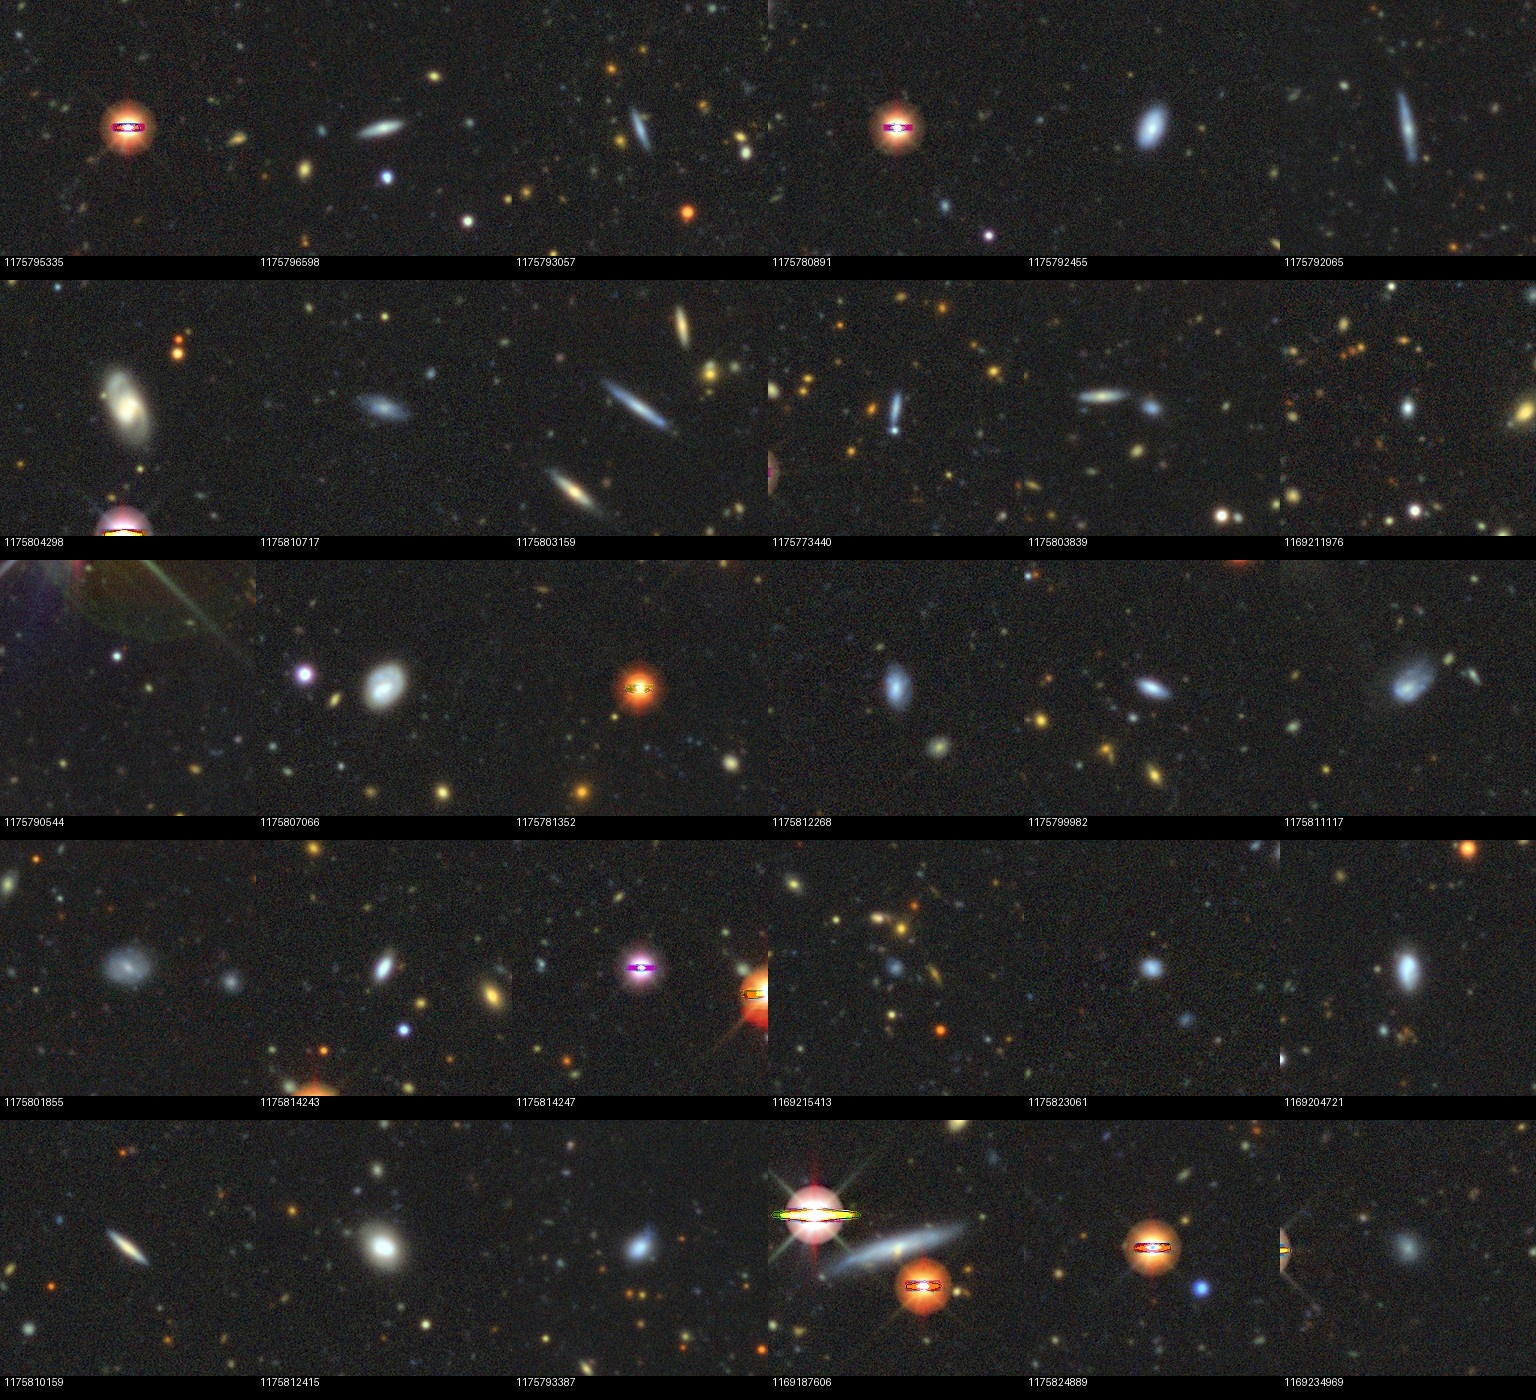

In [14]:
# ============================================================
# CELL 12 — Legacy Viewer cutouts + contact sheets
# for SECONDARY ISLAND candidates only
# ============================================================

import os
import time
import shutil
import math
import requests
import pandas as pd

from tqdm.auto import tqdm
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

ISLAND_TO_REVIEW = 2
CUTOUT_DIR = f"cutouts_island{ISLAND_TO_REVIEW}"
SHEET_DIR  = f"sheets_island{ISLAND_TO_REVIEW}"

LAYER = "ls-dr10"
THUMB_SIZE = 256      # same basic size as your earlier notebook
DOWNLOAD_SIZE = 256   # JPEG cutout size from Legacy Viewer
COLS = 6
ROWS = 5
PER_SHEET = COLS * ROWS
REQUEST_TIMEOUT = 15
SLEEP_BETWEEN = 0.05  # polite tiny pause between requests

# ------------------------------------------------------------
# LOAD secondary-island catalogue
# ------------------------------------------------------------

if "des_candidates_820" in globals():
    base = des_candidates_820.copy()
else:
    base = pd.read_csv(
        OUTPUT_DIR / "GW190814_candidates_full90_legacy_photoz_preclean.csv"
    )

required = {"coadd_object_id", "ra", "dec", "island_id"}
missing = required - set(base.columns)
if missing:
    raise ValueError(f"Base catalogue is missing required columns: {missing}")

secondary = (
    base[base["island_id"] == ISLAND_TO_REVIEW]
    .copy()
    .sort_values(
        ["gw_credible_level", "ra", "dec"]
        if {"gw_credible_level", "ra", "dec"}.issubset(base.columns)
        else ["ra", "dec"]
    )
    .reset_index(drop=True)
)

print(f"Secondary-island rows to inspect: {len(secondary)}")

if len(secondary) == 0:
    raise RuntimeError("No secondary-island rows found.")

# Save the review list itself for convenience
review_csv = OUTPUT_DIR / f"GW190814_island{ISLAND_TO_REVIEW}_review_list.csv"
secondary.to_csv(review_csv, index=False)
print(f"Saved review list: {review_csv}")

# ------------------------------------------------------------
# START FRESH output folders
# ------------------------------------------------------------

if os.path.exists(CUTOUT_DIR):
    shutil.rmtree(CUTOUT_DIR)
if os.path.exists(SHEET_DIR):
    shutil.rmtree(SHEET_DIR)

os.makedirs(CUTOUT_DIR, exist_ok=True)
os.makedirs(SHEET_DIR, exist_ok=True)

# ------------------------------------------------------------
# Legacy cutout fetcher
# ------------------------------------------------------------

def fetch_cutout(ra, dec, obj_id, size=256, layer="ls-dr10", out_dir="."):
    """
    Fetch a JPEG cutout from Legacy Surveys viewer.
    """
    url = (
        "https://www.legacysurvey.org/viewer/cutout.jpg"
        f"?ra={ra}&dec={dec}&layer={layer}&width={size}&height={size}"
    )

    try:
        r = requests.get(url, timeout=REQUEST_TIMEOUT)
        r.raise_for_status()

        ctype = r.headers.get("Content-Type", "")
        if not ctype.startswith("image/jpeg"):
            print(f"Non-image response for {obj_id}: {ctype}")
            return False

        fname = os.path.join(out_dir, f"{obj_id}.jpg")
        with open(fname, "wb") as f:
            f.write(r.content)
        return True

    except Exception as e:
        print(f"Failed for {obj_id} at RA={ra}, Dec={dec}: {e}")
        return False

# ------------------------------------------------------------
# Download cutouts
# ------------------------------------------------------------

download_ok = []
download_fail = []

for _, row in tqdm(secondary.iterrows(), total=len(secondary)):
    obj_id = int(row["coadd_object_id"])
    ra = float(row["ra"])
    dec = float(row["dec"])

    ok = fetch_cutout(
        ra=ra,
        dec=dec,
        obj_id=obj_id,
        size=DOWNLOAD_SIZE,
        layer=LAYER,
        out_dir=CUTOUT_DIR
    )

    if ok:
        download_ok.append(obj_id)
    else:
        download_fail.append(obj_id)

    time.sleep(SLEEP_BETWEEN)

print(f"\nDownloaded successfully: {len(download_ok)}")
print(f"Failed downloads:        {len(download_fail)}")

# Save failed IDs if any
if download_fail:
    fail_df = secondary[secondary["coadd_object_id"].isin(download_fail)].copy()
    fail_csv = OUTPUT_DIR / f"GW190814_island{ISLAND_TO_REVIEW}_cutout_failures.csv"
    fail_df.to_csv(fail_csv, index=False)
    print(f"Saved failures list: {fail_csv}")

# ------------------------------------------------------------
# Build contact sheets
# ------------------------------------------------------------

obj_ids = list(secondary["coadd_object_id"])
n = len(obj_ids)
n_sheets = math.ceil(n / PER_SHEET)

print(f"\nTotal objects: {n}")
print(f"Sheets to create: {n_sheets}")

try:
    font = ImageFont.truetype("arial.ttf", 18)
except Exception:
    font = ImageFont.load_default()

for sheet_idx in range(n_sheets):
    start = sheet_idx * PER_SHEET
    end   = min((sheet_idx + 1) * PER_SHEET, n)
    subset = obj_ids[start:end]

    sheet_width  = COLS * THUMB_SIZE
    sheet_height = ROWS * (THUMB_SIZE + 24)

    sheet = Image.new("RGB", (sheet_width, sheet_height), "black")
    draw = ImageDraw.Draw(sheet)

    for i, obj_id in enumerate(subset):
        r = i // COLS
        c = i % COLS
        x = c * THUMB_SIZE
        y = r * (THUMB_SIZE + 24)

        fname = os.path.join(CUTOUT_DIR, f"{obj_id}.jpg")

        if os.path.exists(fname):
            try:
                im = Image.open(fname).convert("RGB")
                im = im.resize((THUMB_SIZE, THUMB_SIZE))
                sheet.paste(im, (x, y))
            except Exception:
                draw.rectangle(
                    [x, y, x + THUMB_SIZE - 1, y + THUMB_SIZE - 1],
                    outline="red",
                    width=3
                )
                draw.text((x + 6, y + 6), "IMAGE ERROR", fill="white", font=font)
        else:
            draw.rectangle(
                [x, y, x + THUMB_SIZE - 1, y + THUMB_SIZE - 1],
                outline="red",
                width=3
            )
            draw.text((x + 6, y + 6), "MISSING", fill="white", font=font)

        draw.text(
            (x + 4, y + THUMB_SIZE),
            str(obj_id),
            fill="white",
            font=font
        )

    outname = os.path.join(
        SHEET_DIR,
        f"island{ISLAND_TO_REVIEW}_sheet_{sheet_idx + 1:02d}.jpg"
    )
    sheet.save(outname, quality=95)
    print("Saved", outname)

# ------------------------------------------------------------
# Display first sheet inline
# ------------------------------------------------------------

first_sheet = os.path.join(
    SHEET_DIR,
    f"island{ISLAND_TO_REVIEW}_sheet_01.jpg"
)

if os.path.exists(first_sheet):
    display(Image.open(first_sheet))
else:
    print("No sheet was created.")

In [16]:
# ============================================================
# CELL 13 — Apply manual visual-cleaning decisions to island 2
# ============================================================

BAD_ISLAND2_IDS = [
    1175795335,
    1175780891,
    1175790544,
    1175814247,
    1175824889,
    1169187606,
    1175559197,
    1169189488,
    1175427403,
    1175428448,
    1182126510,
    1175439313,
    1175429286,
    1175428959,
    1175436221,
    1175434228,
    1175433741,
    1175433066,
    1175433376,
    1175555458,
    1175431210,
    1175765402,
    1181751945,
    1175434131,
    1175435323,
    1175438042,
    1169196587,
    1175454463,
    1182116544,
    1182120366,
    1169197577,
    1169191767,
    1182096358,
    1182096747,
    1169307606,
    1182080938,
    1169446078,
    1181771891,
    1175473058,
    1169303509,
    1169189890,
    1175455697,
    1175451279,
    1175450150,
    1169234692,
    1175475516,
    1175470965,
    1181788975,
    1182063835,
    1182066785,
    1169227874,
    1169228138,
    1181773823,
    1175460128,
    1175520376,
    1175527117,
    1181777310,
    1182394250,
    1183174573,
    1181772732,
    1188392381,
    1175487225,
    1182394986,
    1181791753,
    1188342303,
    1181777892,
    1169280216,
    1169285187,
    1182401169,
    1169205828,
    1169202186,
    1182070805,
    1188726440,
    1182405625,
    1175116137,
    1175505474,
    1183186427,
    1164146986,
    1181785071,
    1181789328,
    1183164078,
    1169229323,
    1188726408,
    1175517233,
    1182409053,
    1182415428,
    1175130836,
    1175130280,
    1188337109,
    1169219953,
    1188749444,
    1183162229,
    1183158973,
    1188743089,
    1168542239,
    1182420660,
    1164116224,
    1182420877,
    1183177040,
    1182420444,
    1164115441,
    1168574355,
]

bad_ids = set(BAD_ISLAND2_IDS)

print(f"Manual reject IDs supplied: {len(BAD_ISLAND2_IDS)}")
print(f"Unique reject IDs:          {len(bad_ids)}")

assert len(BAD_ISLAND2_IDS) == len(bad_ids), \
    "Duplicate IDs found in manual reject list."


# ------------------------------------------------------------
# Recover island-2 sample if necessary
# ------------------------------------------------------------

if "secondary" in globals():
    island2_preclean = secondary.copy()
elif "des_candidates_820" in globals():
    island2_preclean = (
        des_candidates_820[
            des_candidates_820["island_id"] == 2
        ].copy()
    )
else:
    island2_preclean = pd.read_csv(
        OUTPUT_DIR / "GW190814_island2_candidates_preclean.csv"
    )

island2_preclean["coadd_object_id"] = (
    island2_preclean["coadd_object_id"].astype(int)
)


# ------------------------------------------------------------
# Verify every manually rejected ID really belongs here
# ------------------------------------------------------------

sample_ids = set(island2_preclean["coadd_object_id"])

missing_ids = sorted(bad_ids - sample_ids)

print(f"\nIsland-2 candidates before cleaning: {len(island2_preclean)}")
print(f"Reject IDs found in sample:          {len(bad_ids & sample_ids)}")
print(f"Reject IDs NOT found in sample:      {len(missing_ids)}")

if missing_ids:
    print("\nMissing IDs:")
    print(missing_ids)

assert not missing_ids, \
    "Some manual reject IDs were not found in the island-2 candidate sample."


# ------------------------------------------------------------
# Separate rejected and retained objects
# ------------------------------------------------------------

island2_rejected = island2_preclean[
    island2_preclean["coadd_object_id"].isin(bad_ids)
].copy()

island2_rejected["visual_decision"] = "reject"
island2_rejected["visual_reason"] = "manual image inspection"

island2_clean = island2_preclean[
    ~island2_preclean["coadd_object_id"].isin(bad_ids)
].copy()

island2_clean["visual_decision"] = "keep"


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("\n--- Island 2 visual cleaning ---")
print(f"Before inspection: {len(island2_preclean)}")
print(f"Rejected:          {len(island2_rejected)}")
print(f"Retained:          {len(island2_clean)}")


# ------------------------------------------------------------
# Save both the reject log and clean sample
# ------------------------------------------------------------

REJECT_FILE = OUTPUT_DIR / "GW190814_island2_visual_rejects.csv"
CLEAN_FILE  = OUTPUT_DIR / "GW190814_island2_visual_clean.csv"

island2_rejected.to_csv(REJECT_FILE, index=False)
island2_clean.to_csv(CLEAN_FILE, index=False)

print("\nSaved:")
print(f" - {REJECT_FILE}")
print(f" - {CLEAN_FILE}")


# ------------------------------------------------------------
# Expected-count sanity checks
# ------------------------------------------------------------

assert len(island2_preclean) == 230
assert len(island2_rejected) == 102
assert len(island2_clean) == 128

print("\nIsland-2 visual cleaning successfully applied.")

Manual reject IDs supplied: 102
Unique reject IDs:          102

Island-2 candidates before cleaning: 230
Reject IDs found in sample:          102
Reject IDs NOT found in sample:      0

--- Island 2 visual cleaning ---
Before inspection: 230
Rejected:          102
Retained:          128

Saved:
 - GW190814_full_90pct/GW190814_island2_visual_rejects.csv
 - GW190814_full_90pct/GW190814_island2_visual_clean.csv

Island-2 visual cleaning successfully applied.


In [18]:
# ============================================================
# CELL 15 — Identify the main-island object missed by the
# old centre-derived SQL rectangle
# ============================================================

# Historical rectangle used in the old notebook
OLD_RA_MIN  = 10.2392578125
OLD_RA_MAX  = 14.8974609375
OLD_DEC_MIN = -27.3215904756
OLD_DEC_MAX = -22.2256480484


# ------------------------------------------------------------
# Current complete main-island sample
# ------------------------------------------------------------

new_main = (
    des_candidates_820[
        des_candidates_820["island_id"] == 1
    ]
    .copy()
)

new_main["coadd_object_id"] = (
    new_main["coadd_object_id"].astype(np.int64)
)


# ------------------------------------------------------------
# Reimpose the HISTORICAL query rectangle
# ------------------------------------------------------------

inside_old_rectangle = (
    (new_main["ra"]  >= OLD_RA_MIN)
    &
    (new_main["ra"]  <= OLD_RA_MAX)
    &
    (new_main["dec"] >= OLD_DEC_MIN)
    &
    (new_main["dec"] <= OLD_DEC_MAX)
)

historical_589 = (
    new_main[
        inside_old_rectangle
    ]
    .copy()
)

rectangle_missed = (
    new_main[
        ~inside_old_rectangle
    ]
    .copy()
)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("--- Historical rectangle reconciliation ---")
print(f"Complete current main island:     {len(new_main)}")
print(f"Inside old SQL rectangle:         {len(historical_589)}")
print(f"Missed by old SQL rectangle:      {len(rectangle_missed)}")


print("\nObject(s) missed by the old rectangle:")

display(
    rectangle_missed[
        [
            "coadd_object_id",
            "ra",
            "dec",
            "mag_auto_i",
            "dnf_z",
            "gw_credible_level",
        ]
    ]
)


# ------------------------------------------------------------
# Compare historical 589 against old visual keep-list
# ------------------------------------------------------------

historical_ids = set(
    historical_589["coadd_object_id"].astype(np.int64)
)

old_keep_ids = set(
    old_keep["coadd_object_id"].astype(np.int64)
)

historical_reject_ids = (
    historical_ids - old_keep_ids
)

print("\n--- Historical visual-cleaning accounting ---")
print(f"Historical pre-cleaning sample: {len(historical_ids)}")
print(f"Old visually retained:          {len(old_keep_ids)}")
print(f"Old visually rejected:          {len(historical_reject_ids)}")


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert len(new_main) == 590
assert len(historical_589) == 589
assert len(rectangle_missed) == 1

assert len(old_keep_ids) == 478
assert len(historical_reject_ids) == 111

assert old_keep_ids.issubset(historical_ids)

print(
    "\nSuccess: old 589 fully explained. "
    "One valid main-island object was clipped by the historical SQL rectangle."
)

--- Historical rectangle reconciliation ---
Complete current main island:     590
Inside old SQL rectangle:         589
Missed by old SQL rectangle:      1

Object(s) missed by the old rectangle:


,coadd_object_id,ra,dec,mag_auto_i,dnf_z,gw_credible_level
585,1092386628,10.882396,-22.210934,17.98506,0.04823,0.898931



--- Historical visual-cleaning accounting ---
Historical pre-cleaning sample: 589
Old visually retained:          478
Old visually rejected:          111

Success: old 589 fully explained. One valid main-island object was clipped by the historical SQL rectangle.


coadd_object_id: 1092386628
RA, Dec:         10.882396, -22.210934
DNF z:           0.04823
i magnitude:     17.985
GW credible:     0.898931


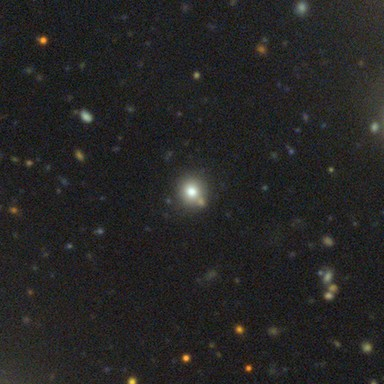

In [19]:
# ============================================================
# CELL 16 — Inspect the one main-island object missed by
# the historical query rectangle
# ============================================================

import requests
from PIL import Image
from IPython.display import display
from io import BytesIO

obj = rectangle_missed.iloc[0]

obj_id = int(obj["coadd_object_id"])
ra = float(obj["ra"])
dec = float(obj["dec"])

url = (
    "https://www.legacysurvey.org/viewer/cutout.jpg"
    f"?ra={ra}&dec={dec}"
    "&layer=ls-dr10"
    "&width=384&height=384"
)

print(f"coadd_object_id: {obj_id}")
print(f"RA, Dec:         {ra:.6f}, {dec:.6f}")
print(f"DNF z:           {obj['dnf_z']:.5f}")
print(f"i magnitude:     {obj['mag_auto_i']:.3f}")
print(f"GW credible:     {obj['gw_credible_level']:.6f}")

r = requests.get(url, timeout=20)
r.raise_for_status()

img = Image.open(BytesIO(r.content)).convert("RGB")
display(img)

In [20]:
# ============================================================
# CELL 17 — Build the final visually cleaned two-island
# GW190814 master catalogue
# ============================================================

BOUNDARY_STAR_ID = 1092386628


# ------------------------------------------------------------
# 1. Rebuild the 478 retained main-island objects using
#    the NEW catalogue, preserving all new GW metadata
# ------------------------------------------------------------

main_clean = (
    new_main[
        new_main["coadd_object_id"].astype(np.int64).isin(old_keep_ids)
    ]
    .copy()
)

main_clean["visual_decision"] = "keep"
main_clean["visual_review_source"] = "historical_manual_review"


# ------------------------------------------------------------
# 2. Confirm the newly discovered boundary object is rejected
# ------------------------------------------------------------

boundary_reject = (
    new_main[
        new_main["coadd_object_id"].astype(np.int64)
        == BOUNDARY_STAR_ID
    ]
    .copy()
)

assert len(boundary_reject) == 1

boundary_reject["visual_decision"] = "reject"
boundary_reject["visual_reason"] = "star"
boundary_reject["visual_review_source"] = "2026_manual_review"


# ------------------------------------------------------------
# 3. Prepare the cleaned secondary-island sample
# ------------------------------------------------------------

island2_clean_final = island2_clean.copy()

island2_clean_final["visual_decision"] = "keep"
island2_clean_final["visual_review_source"] = "2026_manual_review"


# ------------------------------------------------------------
# 4. Combine both islands
# ------------------------------------------------------------

master_606 = pd.concat(
    [
        main_clean,
        island2_clean_final
    ],
    ignore_index=True
)

master_606 = (
    master_606
    .sort_values(
        ["island_id", "gw_credible_level", "ra", "dec"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Give the cleaned catalogue a stable object number
# ------------------------------------------------------------

if "master_id" in master_606.columns:
    master_606 = master_606.drop(columns=["master_id"])

master_606.insert(
    0,
    "master_id",
    np.arange(1, len(master_606) + 1)
)


# ------------------------------------------------------------
# 6. Diagnostics
# ------------------------------------------------------------

print("--- Final visually cleaned GW190814 catalogue ---")
print(f"Main island retained:      {len(main_clean)}")
print(f"Secondary island retained: {len(island2_clean_final)}")
print(f"TOTAL:                     {len(master_606)}")

print("\nBy island:")
print(
    master_606["island_id"]
    .value_counts()
    .sort_index()
)

print(
    f"\nDuplicate coadd_object_id values: "
    f"{master_606['coadd_object_id'].duplicated().sum()}"
)


# ------------------------------------------------------------
# 7. Save final catalogue
# ------------------------------------------------------------

MASTER_FILE = (
    OUTPUT_DIR /
    "GW190814_full90_visual_clean_master_606.csv"
)

BOUNDARY_REJECT_FILE = (
    OUTPUT_DIR /
    "GW190814_main_island_boundary_star_reject.csv"
)

master_606.to_csv(
    MASTER_FILE,
    index=False
)

boundary_reject.to_csv(
    BOUNDARY_REJECT_FILE,
    index=False
)


print("\nSaved:")
print(f" - {MASTER_FILE}")
print(f" - {BOUNDARY_REJECT_FILE}")


# ------------------------------------------------------------
# 8. Hard sanity checks
# ------------------------------------------------------------

assert len(main_clean) == 478
assert len(island2_clean_final) == 128
assert len(master_606) == 606

assert (
    master_606["island_id"]
    .value_counts()
    .sort_index()
    .to_dict()
    == {1: 478, 2: 128}
)

assert master_606["coadd_object_id"].is_unique

assert BOUNDARY_STAR_ID not in set(
    master_606["coadd_object_id"].astype(np.int64)
)

print("\n606-object master catalogue successfully created.")

--- Final visually cleaned GW190814 catalogue ---
Main island retained:      478
Secondary island retained: 128
TOTAL:                     606

By island:
island_id
1    478
2    128
Name: count, dtype: int64

Duplicate coadd_object_id values: 0

Saved:
 - GW190814_full_90pct/GW190814_full90_visual_clean_master_606.csv
 - GW190814_full_90pct/GW190814_main_island_boundary_star_reject.csv

606-object master catalogue successfully created.


In [23]:
# ============================================================
# CELL 18 — Gaia DR3 crossmatch and conservative star veto
# Complete 606-object visually cleaned catalogue
#
# Reproduces the old methodology:
#   - nearest Gaia DR3 source
#   - match radius = 1 arcsec
#   - star veto if:
#         |parallax / parallax_error| > 5
#                     OR
#         |pm_tot / pm_tot_err| > 5
#
# Runs separately over the two compact GW-island query boxes.
# ============================================================

import numpy as np
import pandas as pd

from astropy.coordinates import SkyCoord
import astropy.units as u


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

GAIA_MATCH_RADIUS = 1.0 * u.arcsec
GAIA_SIGMA_THRESHOLD = 5.0
GAIA_MAXREC = 500_000

GAIA_FULL_FILE = (
    OUTPUT_DIR /
    "GW190814_master606_with_gaia_veto.csv"
)

GAIA_VETO_FILE = (
    OUTPUT_DIR /
    "GW190814_master606_gaia_vetoed_objects.csv"
)

GAIA_CLEAN_FILE = (
    OUTPUT_DIR /
    "GW190814_master606_after_gaia_veto.csv"
)


# ------------------------------------------------------------
# 1. Load 606-object visually cleaned catalogue
# ------------------------------------------------------------

if "master_606" in globals():

    gaia_input = master_606.copy()

else:

    gaia_input = pd.read_csv(
        OUTPUT_DIR /
        "GW190814_full90_visual_clean_master_606.csv"
    )


gaia_input["coadd_object_id"] = (
    gaia_input["coadd_object_id"]
    .astype(np.int64)
)

assert len(gaia_input) == 606
assert gaia_input["coadd_object_id"].is_unique


print(f"Input objects: {len(gaia_input)}")
print(
    "By island:",
    gaia_input["island_id"]
    .value_counts()
    .sort_index()
    .to_dict()
)


# ------------------------------------------------------------
# 2. Query Gaia DR3 in each GW-island rectangle
# ------------------------------------------------------------

gaia_parts = []

for _, box in query_boxes.iterrows():

    island_id = int(box["island_id"])

    ra_min = float(box["ra_min_deg"])
    ra_max = float(box["ra_max_deg"])
    dec_min = float(box["dec_min_deg"])
    dec_max = float(box["dec_max_deg"])
    wraps = bool(box["ra_wraps_zero"])

    if wraps:

        ra_clause = (
            f"(ra >= {ra_min:.10f} "
            f"OR ra <= {ra_max:.10f})"
        )

    else:

        ra_clause = (
            f"(ra BETWEEN {ra_min:.10f} "
            f"AND {ra_max:.10f})"
        )


    adql = f"""
    SELECT
        source_id,
        ra,
        dec,
        parallax,
        parallax_error,
        pmra,
        pmra_error,
        pmdec,
        pmdec_error,
        phot_g_mean_mag
    FROM gaia_dr3.gaia_source
    WHERE
        {ra_clause}
        AND dec BETWEEN {dec_min:.10f} AND {dec_max:.10f}
    """


    print("\n" + "=" * 60)
    print(f"Querying Gaia DR3 around island {island_id}...")
    print(f"RA:  {ra_min:.6f} to {ra_max:.6f}")
    print(f"Dec: {dec_min:.6f} to {dec_max:.6f}")

    result = tap_service.run_async(
        adql,
        maxrec=GAIA_MAXREC
    )

    part = result.to_table().to_pandas()

    print(f"Gaia rows returned: {len(part):,}")

    if len(part) >= GAIA_MAXREC:

        raise RuntimeError(
            f"Gaia island-{island_id} query hit "
            f"MAXREC={GAIA_MAXREC:,}; result may be truncated."
        )

    part["gaia_query_island"] = island_id

    gaia_parts.append(part)


# ------------------------------------------------------------
# 3. Combine Gaia pulls
# ------------------------------------------------------------

gaia_catalogue = pd.concat(
    gaia_parts,
    ignore_index=True
)

gaia_catalogue = (
    gaia_catalogue
    .dropna(subset=["ra", "dec"])
    .reset_index(drop=True)
)


print("\n" + "=" * 60)
print("Gaia catalogue ready")
print("=" * 60)

print(f"Total Gaia rows: {len(gaia_catalogue):,}")

print(
    "Rows by query island:",
    gaia_catalogue["gaia_query_island"]
    .value_counts()
    .sort_index()
    .to_dict()
)


# ------------------------------------------------------------
# 4. Match each GW candidate ONLY against Gaia sources
#    from its own island patch
#
# This prevents any irrelevant cross-island nearest-neighbour
# behaviour and keeps the matching simple.
# ------------------------------------------------------------

matched_parts = []

for island_id in sorted(
    gaia_input["island_id"].astype(int).unique()
):

    gal_part = (
        gaia_input[
            gaia_input["island_id"] == island_id
        ]
        .copy()
        .reset_index(drop=True)
    )

    gaia_part = (
        gaia_catalogue[
            gaia_catalogue["gaia_query_island"] == island_id
        ]
        .copy()
        .reset_index(drop=True)
    )


    print(
        f"\nMatching island {island_id}: "
        f"{len(gal_part)} candidates against "
        f"{len(gaia_part):,} Gaia sources..."
    )


    gal_sky = SkyCoord(
        gal_part["ra"].to_numpy(dtype=float) * u.deg,
        gal_part["dec"].to_numpy(dtype=float) * u.deg,
        frame="icrs"
    )

    gaia_sky = SkyCoord(
        gaia_part["ra"].to_numpy(dtype=float) * u.deg,
        gaia_part["dec"].to_numpy(dtype=float) * u.deg,
        frame="icrs"
    )


    idx, sep2d, _ = gal_sky.match_to_catalog_sky(
        gaia_sky
    )

    matched = sep2d < GAIA_MATCH_RADIUS


    # --------------------------------------------------------
    # Initialise attached Gaia columns
    # --------------------------------------------------------

    gal_part["gaia_match"] = False
    gal_part["gaia_sep_arcsec"] = np.nan
    gal_part["gaia_source_id"] = pd.NA

    gaia_cols = [
        "parallax",
        "parallax_error",
        "pmra",
        "pmra_error",
        "pmdec",
        "pmdec_error",
        "phot_g_mean_mag",
    ]

    for c in gaia_cols:
        gal_part[c] = np.nan


    # --------------------------------------------------------
    # Attach nearest Gaia source where separation < 1"
    # --------------------------------------------------------

    gal_part.loc[
        matched,
        "gaia_match"
    ] = True

    gal_part.loc[
        matched,
        "gaia_sep_arcsec"
    ] = sep2d[matched].to(u.arcsec).value


    if matched.any():

        gaia_m = (
            gaia_part
            .iloc[idx[matched]]
            .reset_index(drop=True)
        )

        # source_id separately because it is an integer identifier
        gal_part.loc[
            matched,
            "gaia_source_id"
        ] = gaia_m["source_id"].astype(str).values

        for c in gaia_cols:

            gal_part.loc[
                matched,
                c
            ] = gaia_m[c].to_numpy()


    print(
        f"Gaia counterparts within 1 arcsec: "
        f"{int(matched.sum())}"
    )

    matched_parts.append(gal_part)


# ------------------------------------------------------------
# 5. Recombine both islands
# ------------------------------------------------------------

gaia_master = pd.concat(
    matched_parts,
    ignore_index=True
)

# Restore stable master ordering
gaia_master = (
    gaia_master
    .sort_values("master_id")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Compute significance quantities
#
# EXACTLY the same definitions used in the old notebook.
# ------------------------------------------------------------

gaia_master["parallax_snr"] = (
    gaia_master["parallax"]
    /
    gaia_master["parallax_error"]
)


gaia_master["pm_tot"] = np.sqrt(
    gaia_master["pmra"]**2
    +
    gaia_master["pmdec"]**2
)


gaia_master["pm_tot_err"] = np.sqrt(
    gaia_master["pmra_error"]**2
    +
    gaia_master["pmdec_error"]**2
)


gaia_master["pm_snr"] = (
    gaia_master["pm_tot"]
    /
    gaia_master["pm_tot_err"]
)


# ------------------------------------------------------------
# 7. Apply conservative Gaia star veto
#
# Reproduce the old rule exactly:
#
# Gaia match AND
# (
#     |parallax S/N| > 5
#       OR
#     |proper-motion S/N| > 5
# )
# ------------------------------------------------------------

gaia_master["gaia_star_veto"] = (
    gaia_master["gaia_match"]
    &
    (
        (
            gaia_master["parallax_snr"].abs()
            > GAIA_SIGMA_THRESHOLD
        )
        |
        (
            gaia_master["pm_snr"].abs()
            > GAIA_SIGMA_THRESHOLD
        )
    )
)


# ------------------------------------------------------------
# 8. Split vetoed / surviving samples
# ------------------------------------------------------------

gaia_vetoed = (
    gaia_master[
        gaia_master["gaia_star_veto"]
    ]
    .copy()
)

master_after_gaia = (
    gaia_master[
        ~gaia_master["gaia_star_veto"]
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 9. Diagnostics
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("GAIA STAR-VETO RESULTS")
print("=" * 60)

print(f"Input objects:       {len(gaia_master)}")
print(
    f"Gaia matches < 1\": "
    f"{int(gaia_master['gaia_match'].sum())}"
)
print(
    f"Gaia star vetoes:    "
    f"{int(gaia_master['gaia_star_veto'].sum())}"
)
print(f"Objects surviving:   {len(master_after_gaia)}")


# ------------------------------------------------------------
# Results by island
# ------------------------------------------------------------

gaia_summary = (
    gaia_master
    .groupby("island_id")
    .agg(
        input_objects=("coadd_object_id", "size"),
        gaia_matches=("gaia_match", "sum"),
        star_vetoes=("gaia_star_veto", "sum")
    )
)

gaia_summary["surviving"] = (
    gaia_summary["input_objects"]
    -
    gaia_summary["star_vetoes"]
)

print("\nGaia veto by island:")

display(gaia_summary)


# ------------------------------------------------------------
# 10. Save all products
# ------------------------------------------------------------

gaia_master.to_csv(
    GAIA_FULL_FILE,
    index=False
)

gaia_vetoed.to_csv(
    GAIA_VETO_FILE,
    index=False
)

master_after_gaia.to_csv(
    GAIA_CLEAN_FILE,
    index=False
)


print("\nSaved:")
print(f" - {GAIA_FULL_FILE}")
print(f" - {GAIA_VETO_FILE}")
print(f" - {GAIA_CLEAN_FILE}")


# ------------------------------------------------------------
# 11. Sanity checks
# ------------------------------------------------------------

assert len(gaia_master) == 606
assert gaia_master["coadd_object_id"].is_unique

assert (
    len(master_after_gaia)
    +
    len(gaia_vetoed)
    == 606
)

assert not master_after_gaia[
    "gaia_star_veto"
].any()


print("\nGaia stage successfully completed.")

Input objects: 606
By island: {1: 478, 2: 128}

Querying Gaia DR3 around island 1...
RA:  10.175313 to 14.961406
Dec: -27.383584 to -22.165358
Gaia rows returned: 80,800

Querying Gaia DR3 around island 2...
RA:  20.546406 to 23.926250
Dec: -33.619578 to -30.932209
Gaia rows returned: 22,380

Gaia catalogue ready
Total Gaia rows: 103,180
Rows by query island: {1: 80800, 2: 22380}

Matching island 1: 478 candidates against 80,800 Gaia sources...
Gaia counterparts within 1 arcsec: 160

Matching island 2: 128 candidates against 22,380 Gaia sources...
Gaia counterparts within 1 arcsec: 14

GAIA STAR-VETO RESULTS
Input objects:       606
Gaia matches < 1": 174
Gaia star vetoes:    110
Objects surviving:   496

Gaia veto by island:


,input_objects,gaia_matches,star_vetoes,surviving
island_id,,,,
1,478,160,109,369
2,128,14,1,127



Saved:
 - GW190814_full_90pct/GW190814_master606_with_gaia_veto.csv
 - GW190814_full_90pct/GW190814_master606_gaia_vetoed_objects.csv
 - GW190814_full_90pct/GW190814_master606_after_gaia_veto.csv

Gaia stage successfully completed.


In [24]:
# ============================================================
# CELL 19 — Connect to current NED TAP service
# and inspect the NED Object Directory schema
# ============================================================

import pyvo as vo
import pandas as pd

NED_TAP_URL = "https://ned.ipac.caltech.edu/tap"

ned_tap = vo.dal.TAPService(NED_TAP_URL)

print("Connected to NED TAP.")
print("Reading current objdir schema...\n")


schema_query = """
SELECT
    column_name,
    datatype,
    unit,
    description
FROM TAP_SCHEMA.columns
WHERE table_name = 'NEDTAP.objdir'
ORDER BY column_index
"""

ned_schema = (
    ned_tap
    .search(schema_query)
    .to_table()
    .to_pandas()
)

display(ned_schema)

print("\nColumn names:")
print(ned_schema["column_name"].tolist())

Connected to NED TAP.
Reading current objdir schema...



,column_name,datatype,unit,description
0,prefname,CHAR,,preferred object name
1,ra,DOUBLE,deg,RA in decimal degrees of the object Equatorial...
2,dec,DOUBLE,deg,DEC in decimal degrees of the object Equatoria...
3,uncmaja,DOUBLE,arcsec,"Uncertainty Ellipse, Semimajor Axis in arcseconds"
4,uncmina,DOUBLE,arcsec,"Uncertainty Ellipse, Semiminor Axis in arcseconds"
5,uncposa,DOUBLE,deg,"Uncertainty Ellipse, PA in degrees (East of No..."
6,gallon,DOUBLE,deg,Galactic Longitude in degrees of the object
7,gallat,DOUBLE,deg,Galactic Latitude in degrees of the object
8,pos_bibcode,CHAR,,Reference Code for the object position
9,prefphytype,CHAR,,NED preferred object type



Column names:
['prefname', 'ra', 'dec', 'uncmaja', 'uncmina', 'uncposa', 'gallon', 'gallat', 'pos_bibcode', 'prefphytype', 'z', 'zunc', 'z_bibcode', 'zflag', 'n_crosref', 'n_notes', 'n_gphot', 'n_posd', 'n_zdf', 'n_ddf', 'n_dist', 'n_class', 'n_images', 'n_spectra', 'objid', 'type_key']


In [27]:
# ============================================================
# CELL 20 — Batched NED TAP queries around the 496 surviving
# galaxy candidates
#
# Instead of scanning whole island rectangles, query NED only
# within 10 arcsec of the actual candidate positions.
#
# 496 candidates / 20 per batch ≈ 25 small TAP queries.
# ============================================================

import time
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

NED_SEARCH_RADIUS_ARCSEC = 10.0
NED_SEARCH_RADIUS_DEG = NED_SEARCH_RADIUS_ARCSEC / 3600.0

BATCH_SIZE = 20
NED_MAXREC = 20_000
PAUSE_BETWEEN_BATCHES = 0.5

NED_BATCH_FILE = (
    OUTPUT_DIR /
    "GW190814_NED_candidate_neighbourhoods.csv"
)


# ------------------------------------------------------------
# 1. Load post-Gaia 496-object sample
# ------------------------------------------------------------

if "master_after_gaia" in globals():
    ned_candidates = master_after_gaia.copy()
else:
    ned_candidates = pd.read_csv(
        OUTPUT_DIR /
        "GW190814_master606_after_gaia_veto.csv"
    )

ned_candidates["coadd_object_id"] = (
    ned_candidates["coadd_object_id"].astype(np.int64)
)

assert len(ned_candidates) == 496
assert ned_candidates["coadd_object_id"].is_unique

print(f"Candidates to search around: {len(ned_candidates)}")
print(
    "By island:",
    ned_candidates["island_id"]
    .value_counts()
    .sort_index()
    .to_dict()
)


# ------------------------------------------------------------
# 2. Helper to build one batched spatial query
# ------------------------------------------------------------

def make_ned_batch_query(batch):

    circles = []

    for row in batch.itertuples(index=False):

        ra = float(row.ra)
        dec = float(row.dec)

        clause = (
            "CONTAINS("
            "POINT('ICRS', ra, dec), "
            f"CIRCLE('ICRS', {ra:.10f}, {dec:.10f}, "
            f"{NED_SEARCH_RADIUS_DEG:.12f})"
            ") = 1"
        )

        circles.append(clause)

    spatial_where = "\n        OR ".join(circles)

    query = f"""
    SELECT
        objid,
        prefname,
        ra,
        dec,
        prefphytype,
        z,
        zunc,
        zflag,
        z_bibcode,
        n_zdf,
        n_spectra
    FROM NEDTAP.objdir
    WHERE
        z IS NOT NULL
        AND (
            {spatial_where}
        )
    """

    return query


# ------------------------------------------------------------
# 3. Robust query helper
#
# If a batch somehow times out, recursively split it into
# smaller pieces rather than losing the entire run.
# ------------------------------------------------------------

def query_batch_robust(batch, label=""):

    query = make_ned_batch_query(batch)

    try:

        result = ned_tap.run_sync(
            query,
            maxrec=NED_MAXREC
        )

        df = (
            result
            .to_table()
            .to_pandas()
        )

        return df

    except Exception as e:

        print(
            f"Batch {label} failed with {len(batch)} candidates:"
        )
        print(f"    {type(e).__name__}: {e}")

        # If batch has more than one candidate, split and retry.
        if len(batch) > 1:

            midpoint = len(batch) // 2

            left = batch.iloc[:midpoint].copy()
            right = batch.iloc[midpoint:].copy()

            print(
                f"    Splitting into {len(left)} + "
                f"{len(right)} candidates..."
            )

            df1 = query_batch_robust(
                left,
                label=f"{label}a"
            )

            df2 = query_batch_robust(
                right,
                label=f"{label}b"
            )

            return pd.concat(
                [df1, df2],
                ignore_index=True
            )

        # A single candidate still failed.
        # Record the failure but allow the overall run to continue.
        print(
            f"    Giving up on candidate "
            f"{int(batch.iloc[0]['coadd_object_id'])} "
            f"for now."
        )

        return pd.DataFrame(
            columns=[
                "objid",
                "prefname",
                "ra",
                "dec",
                "prefphytype",
                "z",
                "zunc",
                "zflag",
                "z_bibcode",
                "n_zdf",
                "n_spectra",
            ]
        )


# ------------------------------------------------------------
# 4. Execute batches
# ------------------------------------------------------------

ned_parts = []

n_batches = int(
    np.ceil(len(ned_candidates) / BATCH_SIZE)
)

print(f"Batch size: {BATCH_SIZE}")
print(f"Total batches: {n_batches}\n")


for batch_number, start in enumerate(
    range(0, len(ned_candidates), BATCH_SIZE),
    start=1
):

    stop = min(
        start + BATCH_SIZE,
        len(ned_candidates)
    )

    batch = (
        ned_candidates
        .iloc[start:stop]
        .copy()
    )

    print(
        f"[Batch {batch_number:02d}/{n_batches}] "
        f"Candidates {start + 1}–{stop}..."
    )

    part = query_batch_robust(
        batch,
        label=str(batch_number)
    )

    print(
        f"    NED redshift-bearing objects returned: "
        f"{len(part):,}"
    )

    if len(part) > 0:

        part["ned_batch"] = batch_number

        ned_parts.append(part)

    time.sleep(PAUSE_BETWEEN_BATCHES)


# ------------------------------------------------------------
# 5. Combine returned NED objects
#
# The same NED object could potentially fall inside two nearby
# candidate circles, so remove duplicate NED objids.
# ------------------------------------------------------------

if len(ned_parts) > 0:

    ned_nearby = pd.concat(
        ned_parts,
        ignore_index=True
    )

    print(
        f"\nRows before NED-object deduplication: "
        f"{len(ned_nearby):,}"
    )

    ned_nearby = (
        ned_nearby
        .drop_duplicates(
            subset="objid",
            keep="first"
        )
        .reset_index(drop=True)
    )

else:

    ned_nearby = pd.DataFrame(
        columns=[
            "objid",
            "prefname",
            "ra",
            "dec",
            "prefphytype",
            "z",
            "zunc",
            "zflag",
            "z_bibcode",
            "n_zdf",
            "n_spectra",
            "ned_batch",
        ]
    )


print(
    f"Unique nearby NED objects with redshift: "
    f"{len(ned_nearby):,}"
)


# ------------------------------------------------------------
# 6. Normalise string columns
# ------------------------------------------------------------

for col in [
    "prefname",
    "prefphytype",
    "zflag",
    "z_bibcode",
]:

    if col in ned_nearby.columns:

        ned_nearby[col] = (
            ned_nearby[col]
            .astype("string")
        )


# ------------------------------------------------------------
# 7. Save immediately
# ------------------------------------------------------------

ned_nearby.to_csv(
    NED_BATCH_FILE,
    index=False
)


# ------------------------------------------------------------
# 8. Inspect zflag distribution
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("NED zflag DISTRIBUTION")
print("=" * 60)

if len(ned_nearby) > 0:

    zflag_summary = (
        ned_nearby["zflag"]
        .fillna("<NULL>")
        .replace("", "<BLANK>")
        .value_counts(dropna=False)
        .rename_axis("zflag")
        .reset_index(name="count")
    )

    display(zflag_summary)

else:

    print("No NED redshift-bearing objects returned.")


# ------------------------------------------------------------
# 9. Preferred object-type distribution
# ------------------------------------------------------------

print("\nMost common NED object types:")

if len(ned_nearby) > 0:

    type_summary = (
        ned_nearby["prefphytype"]
        .fillna("<NULL>")
        .value_counts(dropna=False)
        .rename_axis("prefphytype")
        .reset_index(name="count")
    )

    display(type_summary.head(30))


print(f"\nSaved: {NED_BATCH_FILE}")
print("\nBatched NED neighbourhood search complete.")

Candidates to search around: 496
By island: {1: 369, 2: 127}
Batch size: 20
Total batches: 25

[Batch 01/25] Candidates 1–20...
    NED redshift-bearing objects returned: 2
[Batch 02/25] Candidates 21–40...
    NED redshift-bearing objects returned: 4
[Batch 03/25] Candidates 41–60...
    NED redshift-bearing objects returned: 2
[Batch 04/25] Candidates 61–80...
    NED redshift-bearing objects returned: 3
[Batch 05/25] Candidates 81–100...
    NED redshift-bearing objects returned: 2
[Batch 06/25] Candidates 101–120...
    NED redshift-bearing objects returned: 6
[Batch 07/25] Candidates 121–140...
    NED redshift-bearing objects returned: 4
[Batch 08/25] Candidates 141–160...
    NED redshift-bearing objects returned: 4
[Batch 09/25] Candidates 161–180...
    NED redshift-bearing objects returned: 2
[Batch 10/25] Candidates 181–200...
    NED redshift-bearing objects returned: 5
[Batch 11/25] Candidates 201–220...
    NED redshift-bearing objects returned: 4
[Batch 12/25] Candidates

,zflag,count
0,SUN,136
1,SLS,3
2,UUN,1
3,SST,1
4,PUN,1



Most common NED object types:


,prefphytype,count
0,G,140
1,SN,1
2,GClstr,1



Saved: GW190814_full_90pct/GW190814_NED_candidate_neighbourhoods.csv

Batched NED neighbourhood search complete.


In [28]:
# ============================================================
# CELL 21 — Local NED crossmatch and spectroscopic-z assignment
#
# Input:
#   496 post-Gaia galaxy candidates
#   142 nearby NED redshift-bearing objects
#
# Matching methodology:
#   1. Look for NED objects within 5 arcsec
#   2. If none, allow 5–10 arcsec
#   3. Choose nearest NED object in the relevant radius
#
# Spectroscopic assignment:
#   zflag beginning "S" = spectroscopic preferred redshift
#
# Non-spectroscopic NED matches are retained as metadata,
# but are NOT used as z_spec.
# ============================================================

import numpy as np
import pandas as pd

from astropy.coordinates import SkyCoord
import astropy.units as u


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

NED_PRIMARY_RADIUS_ARCSEC = 5.0
NED_FALLBACK_RADIUS_ARCSEC = 10.0

NED_MATCHED_FILE = (
    OUTPUT_DIR /
    "GW190814_496_with_NED_matches.csv"
)

NED_SPEC_FILE = (
    OUTPUT_DIR /
    "GW190814_496_with_specz_zbest.csv"
)

NED_REVIEW_FILE = (
    OUTPUT_DIR /
    "GW190814_NED_matches_needing_review.csv"
)


# ------------------------------------------------------------
# 1. Recover inputs if necessary
# ------------------------------------------------------------

if "master_after_gaia" in globals():
    candidates = master_after_gaia.copy()
else:
    candidates = pd.read_csv(
        OUTPUT_DIR /
        "GW190814_master606_after_gaia_veto.csv"
    )


if "ned_nearby" in globals():
    ned = ned_nearby.copy()
else:
    ned = pd.read_csv(
        OUTPUT_DIR /
        "GW190814_NED_candidate_neighbourhoods.csv"
    )


candidates["coadd_object_id"] = (
    candidates["coadd_object_id"].astype(np.int64)
)

ned["objid"] = ned["objid"].astype(np.int64)


assert len(candidates) == 496
assert candidates["coadd_object_id"].is_unique

print(f"Galaxy candidates:       {len(candidates)}")
print(f"Nearby NED objects:      {len(ned)}")


# ------------------------------------------------------------
# 2. Normalise NED zflag
# ------------------------------------------------------------

ned["zflag_clean"] = (
    ned["zflag"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
)

# First character S = spectroscopic technique.
# A '?' anywhere marks questionable quality.
ned["ned_preferred_is_specz"] = (
    ned["zflag_clean"].str.startswith("S")
    &
    ~ned["zflag_clean"].str.contains(
        r"\?",
        regex=True
    )
)


print(
    f"Spectroscopic preferred NED redshifts: "
    f"{int(ned['ned_preferred_is_specz'].sum())}"
)

print(
    f"Non-spectroscopic/unknown preferred redshifts: "
    f"{int((~ned['ned_preferred_is_specz']).sum())}"
)


# ------------------------------------------------------------
# 3. Build coordinate arrays
# ------------------------------------------------------------

candidate_sky = SkyCoord(
    candidates["ra"].to_numpy(dtype=float) * u.deg,
    candidates["dec"].to_numpy(dtype=float) * u.deg,
    frame="icrs"
)

ned_sky = SkyCoord(
    ned["ra"].to_numpy(dtype=float) * u.deg,
    ned["dec"].to_numpy(dtype=float) * u.deg,
    frame="icrs"
)


# ------------------------------------------------------------
# 4. For every candidate, find the appropriate NED match
#
# Because there are only 496 x 142 objects, a transparent
# per-candidate calculation is trivial and avoids ambiguity
# about search_around_sky index ordering.
# ------------------------------------------------------------

match_records = []


for i, candidate in candidates.iterrows():

    separations = (
        candidate_sky[i]
        .separation(ned_sky)
        .to(u.arcsec)
        .value
    )


    # --------------------------------------------------------
    # First priority: anything within 5 arcsec
    # --------------------------------------------------------

    within_5 = np.where(
        separations <= NED_PRIMARY_RADIUS_ARCSEC
    )[0]


    if len(within_5) > 0:

        j = within_5[
            np.argmin(separations[within_5])
        ]

        radius_class = "within_5arcsec"


    else:

        # ----------------------------------------------------
        # Fallback: 5–10 arcsec
        # ----------------------------------------------------

        within_10 = np.where(
            separations <= NED_FALLBACK_RADIUS_ARCSEC
        )[0]

        if len(within_10) > 0:

            j = within_10[
                np.argmin(separations[within_10])
            ]

            radius_class = "fallback_10arcsec"

        else:

            # No NED redshift-bearing object nearby
            match_records.append({
                "coadd_object_id":
                    int(candidate["coadd_object_id"]),

                "ned_match": False,
                "ned_objid": pd.NA,
                "ned_name": None,
                "ned_type": None,

                "z_ned_preferred": np.nan,
                "z_ned_unc": np.nan,
                "zflag": None,
                "z_bibcode": None,

                "ned_sep_arcsec": np.nan,
                "ned_radius_class": None,

                "ned_preferred_is_specz": False,
            })

            continue


    # --------------------------------------------------------
    # Record selected NED match
    # --------------------------------------------------------

    n = ned.iloc[int(j)]

    match_records.append({
        "coadd_object_id":
            int(candidate["coadd_object_id"]),

        "ned_match": True,

        "ned_objid":
            int(n["objid"]),

        "ned_name":
            str(n["prefname"]),

        "ned_type":
            str(n["prefphytype"]),

        "z_ned_preferred":
            float(n["z"]),

        "z_ned_unc":
            float(n["zunc"])
            if pd.notna(n["zunc"])
            else np.nan,

        "zflag":
            str(n["zflag_clean"]),

        "z_bibcode":
            str(n["z_bibcode"])
            if pd.notna(n["z_bibcode"])
            else None,

        "ned_sep_arcsec":
            float(separations[j]),

        "ned_radius_class":
            radius_class,

        "ned_preferred_is_specz":
            bool(n["ned_preferred_is_specz"]),
    })


# ------------------------------------------------------------
# 5. Merge NED matches into candidate catalogue
# ------------------------------------------------------------

ned_match_table = pd.DataFrame(
    match_records
)


master_ned = candidates.merge(
    ned_match_table,
    on="coadd_object_id",
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 6. Define genuine spectroscopic redshift
#
# z_spec exists ONLY if the selected NED preferred redshift
# is explicitly spectroscopic.
# ------------------------------------------------------------

master_ned["z_spec"] = np.where(
    master_ned["ned_preferred_is_specz"],
    master_ned["z_ned_preferred"],
    np.nan
)

master_ned["z_spec_source"] = np.where(
    master_ned["z_spec"].notna(),
    "NED",
    None
)

master_ned["has_specz"] = (
    master_ned["z_spec"].notna()
)


# ------------------------------------------------------------
# 7. Define z_best
#
# Spectroscopic redshift supersedes DES DNF photo-z.
# Otherwise retain dnf_z.
# ------------------------------------------------------------

master_ned["z_best"] = (
    master_ned["z_spec"]
    .fillna(master_ned["dnf_z"])
)

master_ned["z_best_source"] = np.where(
    master_ned["has_specz"],
    "NED_specz",
    "DES_DNF_photoz"
)


# ------------------------------------------------------------
# 8. Flag matches that deserve manual inspection
#
# Examples:
#   - NED object is not a galaxy
#   - match required 5–10 arcsec fallback
#   - NED preferred redshift isn't spectroscopic
# ------------------------------------------------------------

master_ned["ned_needs_review"] = (
    (
        master_ned["ned_match"]
        &
        (
            master_ned["ned_type"].fillna("") != "G"
        )
    )
    |
    (
        master_ned["ned_radius_class"]
        == "fallback_10arcsec"
    )
    |
    (
        master_ned["ned_match"]
        &
        ~master_ned["ned_preferred_is_specz"]
    )
)


# ------------------------------------------------------------
# 9. Diagnostics
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("NED LOCAL CROSSMATCH RESULTS")
print("=" * 60)

print(
    f"Candidates:                   "
    f"{len(master_ned)}"
)

print(
    f"Any NED redshift match:       "
    f"{int(master_ned['ned_match'].sum())}"
)

print(
    f"Explicit spectroscopic z:     "
    f"{int(master_ned['has_specz'].sum())}"
)

print(
    f"Non-spec/unknown NED matches: "
    f"{int(
        (
            master_ned['ned_match']
            &
            ~master_ned['ned_preferred_is_specz']
        ).sum()
    )}"
)

print(
    f"Matches requiring review:     "
    f"{int(master_ned['ned_needs_review'].sum())}"
)


# ------------------------------------------------------------
# 10. Results by island
# ------------------------------------------------------------

spec_summary = (
    master_ned
    .groupby("island_id")
    .agg(
        galaxies=("coadd_object_id", "size"),
        ned_matches=("ned_match", "sum"),
        specz=("has_specz", "sum"),
        review=("ned_needs_review", "sum"),
    )
)


print("\nResults by island:")

display(spec_summary)


# ------------------------------------------------------------
# 11. Distribution of actual matched zflags
# ------------------------------------------------------------

print("\nMatched NED zflags:")

matched_zflags = (
    master_ned[
        master_ned["ned_match"]
    ]["zflag"]
    .fillna("<NULL>")
    .value_counts()
    .rename_axis("zflag")
    .reset_index(name="count")
)

display(matched_zflags)


# ------------------------------------------------------------
# 12. Objects requiring review
# ------------------------------------------------------------

ned_review = (
    master_ned[
        master_ned["ned_needs_review"]
    ]
    .copy()
)


if len(ned_review) > 0:

    print("\nNED matches needing review:")

    review_cols = [
        "coadd_object_id",
        "island_id",
        "ned_name",
        "ned_type",
        "z_ned_preferred",
        "zflag",
        "ned_sep_arcsec",
        "ned_radius_class",
        "dnf_z",
    ]

    display(
        ned_review[
            review_cols
        ].sort_values(
            "ned_sep_arcsec"
        )
    )


# ------------------------------------------------------------
# 13. Save products
# ------------------------------------------------------------

master_ned.to_csv(
    NED_MATCHED_FILE,
    index=False
)

master_ned.to_csv(
    NED_SPEC_FILE,
    index=False
)

ned_review.to_csv(
    NED_REVIEW_FILE,
    index=False
)


print("\nSaved:")
print(f" - {NED_MATCHED_FILE}")
print(f" - {NED_SPEC_FILE}")
print(f" - {NED_REVIEW_FILE}")


# ------------------------------------------------------------
# 14. Sanity checks
# ------------------------------------------------------------

assert len(master_ned) == 496
assert master_ned["coadd_object_id"].is_unique

assert np.all(
    master_ned.loc[
        master_ned["has_specz"],
        "z_best"
    ]
    ==
    master_ned.loc[
        master_ned["has_specz"],
        "z_spec"
    ]
)

assert np.all(
    master_ned.loc[
        ~master_ned["has_specz"],
        "z_best"
    ]
    ==
    master_ned.loc[
        ~master_ned["has_specz"],
        "dnf_z"
    ]
)


print(
    "\nNED spectroscopic-redshift stage "
    "successfully completed."
)

Galaxy candidates:       496
Nearby NED objects:      142
Spectroscopic preferred NED redshifts: 140
Non-spectroscopic/unknown preferred redshifts: 2

NED LOCAL CROSSMATCH RESULTS
Candidates:                   496
Any NED redshift match:       141
Explicit spectroscopic z:     140
Non-spec/unknown NED matches: 1
Matches requiring review:     4

Results by island:


,galaxies,ned_matches,specz,review
island_id,,,,
1,369,65,64,2
2,127,76,76,2



Matched NED zflags:


,zflag,count
0,SUN,137
1,SLS,3
2,PUN,1



NED matches needing review:


,coadd_object_id,island_id,ned_name,ned_type,z_ned_preferred,zflag,ned_sep_arcsec,ned_radius_class,dnf_z
234,1097473397,1,WISEA J004633.79-260820.7,G,0.09938,PUN,0.123059,within_5arcsec,0.053120
120,1108795753,1,PTF11hrq,SN,0.05710,SUN,0.490525,within_5arcsec,0.046192
486,1175505437,2,WISEA J012703.45-311018.2,G,0.05910,SUN,5.007810,fallback_10arcsec,0.060340
488,1175504898,2,WISEA J012709.79-310957.1,G,0.05890,SUN,7.195648,fallback_10arcsec,0.044825



Saved:
 - GW190814_full_90pct/GW190814_496_with_NED_matches.csv
 - GW190814_full_90pct/GW190814_496_with_specz_zbest.csv
 - GW190814_full_90pct/GW190814_NED_matches_needing_review.csv

NED spectroscopic-redshift stage successfully completed.


--- NED matches requiring manual review ---


,coadd_object_id,island_id,ned_name,ned_type,z_ned_preferred,zflag,dnf_z,delta_z_ned_minus_dnf,ned_sep_arcsec,ned_radius_class
1,1097473397,1,WISEA J004633.79-260820.7,G,0.09938,PUN,0.053120,0.046260,0.123059,within_5arcsec
0,1108795753,1,PTF11hrq,SN,0.05710,SUN,0.046192,0.010908,0.490525,within_5arcsec
2,1175505437,2,WISEA J012703.45-311018.2,G,0.05910,SUN,0.060340,-0.001240,5.007810,fallback_10arcsec
3,1175504898,2,WISEA J012709.79-310957.1,G,0.05890,SUN,0.044825,0.014075,7.195648,fallback_10arcsec



DES candidate: 1097473397
NED: WISEA J004633.79-260820.7 (G)
Separation: 0.123 arcsec
DNF z = 0.053120
NED preferred z = 0.099380 [PUN]


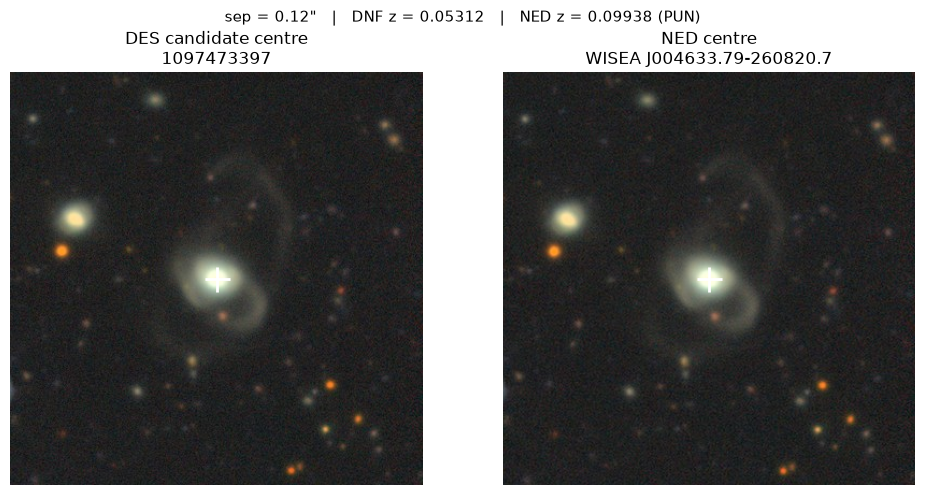


DES candidate: 1108795753
NED: PTF11hrq (SN)
Separation: 0.491 arcsec
DNF z = 0.046192
NED preferred z = 0.057100 [SUN]


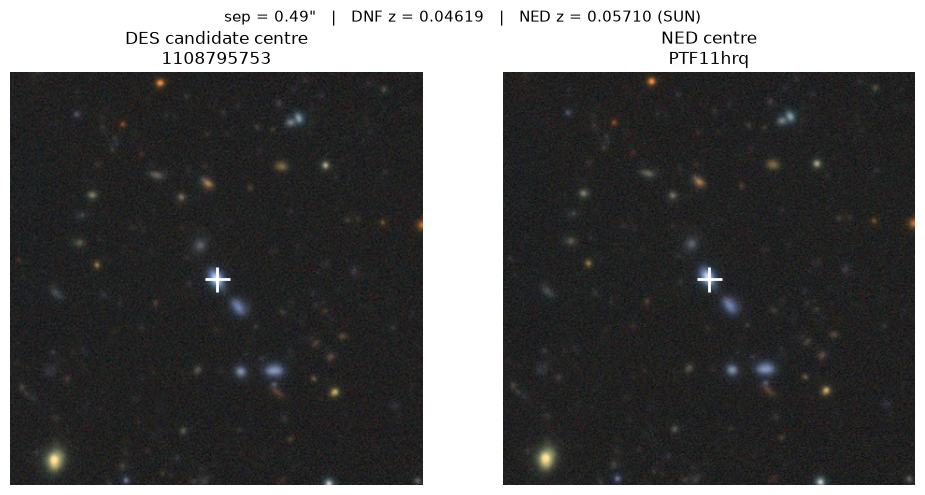


DES candidate: 1175505437
NED: WISEA J012703.45-311018.2 (G)
Separation: 5.008 arcsec
DNF z = 0.060340
NED preferred z = 0.059100 [SUN]


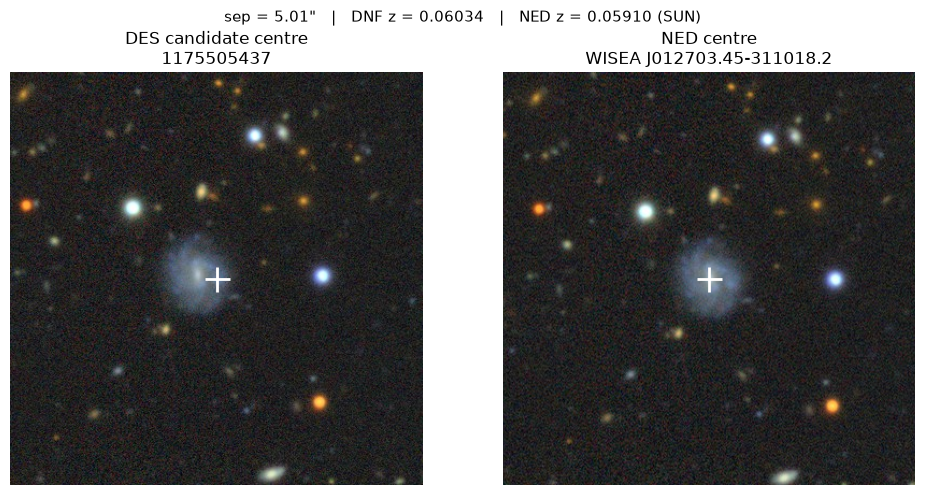


DES candidate: 1175504898
NED: WISEA J012709.79-310957.1 (G)
Separation: 7.196 arcsec
DNF z = 0.044825
NED preferred z = 0.058900 [SUN]


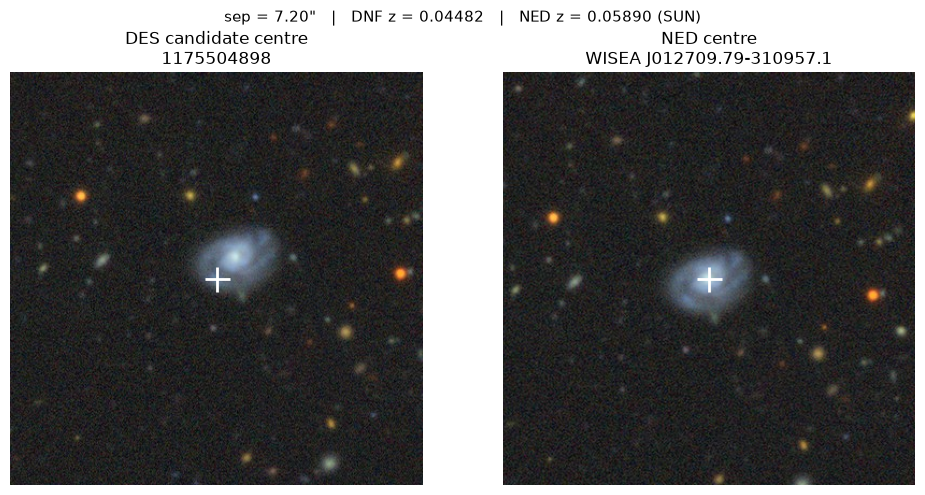

In [29]:
# ============================================================
# CELL 22 — Visual review of ambiguous NED matches
#
# Displays, for each review case:
#   LEFT:  Legacy cutout centred on the DES candidate
#   RIGHT: Legacy cutout centred on the NED counterpart
#
# This lets us judge:
#   - whether the SN is clearly associated with the host galaxy
#   - whether the 5–10 arcsec fallback matches are really the
#     same extended galaxy
# ============================================================

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from io import BytesIO


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

CUTOUT_SIZE = 384
LEGACY_LAYER = "ls-dr10"


# ------------------------------------------------------------
# 1. Recover review table if necessary
# ------------------------------------------------------------

if "ned_review" in globals():

    review = ned_review.copy()

else:

    review = pd.read_csv(
        OUTPUT_DIR /
        "GW190814_NED_matches_needing_review.csv"
    )


review["coadd_object_id"] = (
    review["coadd_object_id"].astype(np.int64)
)


# ------------------------------------------------------------
# 2. Recover the complete matched catalogue
#    because we need the actual NED RA/Dec as well
# ------------------------------------------------------------

if "master_ned" in globals():

    full_ned = master_ned.copy()

else:

    full_ned = pd.read_csv(
        OUTPUT_DIR /
        "GW190814_496_with_NED_matches.csv"
    )


full_ned["coadd_object_id"] = (
    full_ned["coadd_object_id"].astype(np.int64)
)


# ------------------------------------------------------------
# 3. Attach NED coordinates from the downloaded NED catalogue
# ------------------------------------------------------------

if "ned_nearby" in globals():

    ned_positions = ned_nearby[
        ["objid", "ra", "dec"]
    ].copy()

else:

    ned_positions = pd.read_csv(
        OUTPUT_DIR /
        "GW190814_NED_candidate_neighbourhoods.csv"
    )[
        ["objid", "ra", "dec"]
    ].copy()


ned_positions["objid"] = (
    ned_positions["objid"].astype(np.int64)
)

ned_positions = ned_positions.rename(
    columns={
        "ra": "ned_ra",
        "dec": "ned_dec"
    }
)


review = review.merge(
    ned_positions,
    left_on="ned_objid",
    right_on="objid",
    how="left",
    validate="many_to_one"
)


# ------------------------------------------------------------
# 4. Useful diagnostic table
# ------------------------------------------------------------

review["delta_z_ned_minus_dnf"] = (
    review["z_ned_preferred"]
    -
    review["dnf_z"]
)


print("--- NED matches requiring manual review ---")

display(
    review[
        [
            "coadd_object_id",
            "island_id",
            "ned_name",
            "ned_type",
            "z_ned_preferred",
            "zflag",
            "dnf_z",
            "delta_z_ned_minus_dnf",
            "ned_sep_arcsec",
            "ned_radius_class",
        ]
    ].sort_values("ned_sep_arcsec")
)


# ------------------------------------------------------------
# 5. Legacy cutout helper
# ------------------------------------------------------------

def get_legacy_cutout(ra, dec, size=384, layer="ls-dr10"):

    url = (
        "https://www.legacysurvey.org/viewer/cutout.jpg"
        f"?ra={ra}"
        f"&dec={dec}"
        f"&layer={layer}"
        f"&width={size}"
        f"&height={size}"
    )

    response = requests.get(
        url,
        timeout=20
    )

    response.raise_for_status()

    return Image.open(
        BytesIO(response.content)
    ).convert("RGB")


# ------------------------------------------------------------
# 6. Display candidate-centred and NED-centred images
# ------------------------------------------------------------

review_sorted = (
    review
    .sort_values("ned_sep_arcsec")
    .reset_index(drop=True)
)


for _, row in review_sorted.iterrows():

    obj_id = int(row["coadd_object_id"])

    candidate_ra = float(row["ra"])
    candidate_dec = float(row["dec"])

    ned_ra = float(row["ned_ra"])
    ned_dec = float(row["ned_dec"])


    print("\n" + "=" * 70)

    print(
        f"DES candidate: {obj_id}"
    )

    print(
        f"NED: {row['ned_name']} "
        f"({row['ned_type']})"
    )

    print(
        f"Separation: {row['ned_sep_arcsec']:.3f} arcsec"
    )

    print(
        f"DNF z = {row['dnf_z']:.6f}"
    )

    print(
        f"NED preferred z = "
        f"{row['z_ned_preferred']:.6f} "
        f"[{row['zflag']}]"
    )


    try:

        img_candidate = get_legacy_cutout(
            candidate_ra,
            candidate_dec,
            size=CUTOUT_SIZE,
            layer=LEGACY_LAYER
        )

        img_ned = get_legacy_cutout(
            ned_ra,
            ned_dec,
            size=CUTOUT_SIZE,
            layer=LEGACY_LAYER
        )


        fig, axes = plt.subplots(
            1,
            2,
            figsize=(10, 5)
        )


        # ----------------------------------------------------
        # DES-centred image
        # ----------------------------------------------------

        axes[0].imshow(img_candidate)

        axes[0].set_title(
            f"DES candidate centre\n"
            f"{obj_id}"
        )

        # mark exact image centre
        cx = CUTOUT_SIZE / 2
        cy = CUTOUT_SIZE / 2

        axes[0].plot(
            cx,
            cy,
            marker="+",
            markersize=18,
            markeredgewidth=2,
            color="white"
        )

        axes[0].axis("off")


        # ----------------------------------------------------
        # NED-centred image
        # ----------------------------------------------------

        axes[1].imshow(img_ned)

        axes[1].set_title(
            f"NED centre\n"
            f"{row['ned_name']}"
        )

        axes[1].plot(
            cx,
            cy,
            marker="+",
            markersize=18,
            markeredgewidth=2,
            color="white"
        )

        axes[1].axis("off")


        fig.suptitle(
            f"sep = {row['ned_sep_arcsec']:.2f}\"   |   "
            f"DNF z = {row['dnf_z']:.5f}   |   "
            f"NED z = {row['z_ned_preferred']:.5f} "
            f"({row['zflag']})",
            fontsize=11
        )

        plt.tight_layout()
        plt.show()


    except Exception as e:

        print(
            f"Could not retrieve Legacy cutout: {e}"
        )

In [30]:
# ============================================================
# CELL 23 — Apply manual NED adjudications and freeze the
# definitive 496-object redshift catalogue
#
# Manual decisions:
#
# 1097473397
#   Same galaxy as NED object, but NED preferred z is
#   photometric (PUN) -> DO NOT use as z_spec.
#
# 1108795753
#   PTF11hrq / host association accepted ->
#   use NED spectroscopic z = 0.05710.
#
# 1175505437
#   5.01" offset lies within same extended galaxy ->
#   use NED spectroscopic z = 0.05910.
#
# 1175504898
#   7.20" offset lies within same extended galaxy ->
#   use NED spectroscopic z = 0.05890.
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Recover Cell-21 catalogue if necessary
# ------------------------------------------------------------

if "master_ned" in globals():

    final_496 = master_ned.copy()

else:

    final_496 = pd.read_csv(
        OUTPUT_DIR /
        "GW190814_496_with_specz_zbest.csv"
    )


final_496["coadd_object_id"] = (
    final_496["coadd_object_id"]
    .astype(np.int64)
)


assert len(final_496) == 496
assert final_496["coadd_object_id"].is_unique


# ------------------------------------------------------------
# 2. Manual adjudication record
# ------------------------------------------------------------

manual_ned_decisions = {

    1097473397: {
        "decision": "reject_as_specz",
        "reason":
            "Secure positional NED association, but preferred "
            "NED redshift is photometric (PUN). Retain DES DNF photo-z."
    },

    1108795753: {
        "decision": "accept_specz",
        "reason":
            "PTF11hrq association accepted; spectroscopic redshift "
            "belongs to the associated host system."
    },

    1175505437: {
        "decision": "accept_specz",
        "reason":
            "NED and DES positions fall on the same extended galaxy; "
            "5.01 arcsec centroid offset accepted."
    },

    1175504898: {
        "decision": "accept_specz",
        "reason":
            "NED and DES positions fall on the same extended galaxy; "
            "7.20 arcsec centroid offset accepted."
    },
}


# Initialise audit columns
final_496["ned_manual_review"] = False
final_496["ned_manual_decision"] = None
final_496["ned_manual_reason"] = None


for obj_id, info in manual_ned_decisions.items():

    m = (
        final_496["coadd_object_id"]
        == obj_id
    )

    assert m.sum() == 1, (
        f"Expected exactly one row for {obj_id}, "
        f"found {m.sum()}."
    )

    final_496.loc[
        m,
        "ned_manual_review"
    ] = True

    final_496.loc[
        m,
        "ned_manual_decision"
    ] = info["decision"]

    final_496.loc[
        m,
        "ned_manual_reason"
    ] = info["reason"]


# ------------------------------------------------------------
# 3. Explicitly enforce the four decisions
# ------------------------------------------------------------


# ---- 1097473397: NED redshift is photometric ----

m = (
    final_496["coadd_object_id"]
    == 1097473397
)

final_496.loc[m, "z_spec"] = np.nan
final_496.loc[m, "z_spec_source"] = None
final_496.loc[m, "has_specz"] = False

final_496.loc[
    m,
    "z_best"
] = final_496.loc[m, "dnf_z"]

final_496.loc[
    m,
    "z_best_source"
] = "DES_DNF_photoz"


# ---- 1108795753: accepted NED spectroscopy ----

m = (
    final_496["coadd_object_id"]
    == 1108795753
)

final_496.loc[m, "z_spec"] = 0.05710
final_496.loc[m, "z_spec_source"] = "NED"
final_496.loc[m, "has_specz"] = True
final_496.loc[m, "z_best"] = 0.05710
final_496.loc[m, "z_best_source"] = "NED_specz"


# ---- 1175505437: accepted NED spectroscopy ----

m = (
    final_496["coadd_object_id"]
    == 1175505437
)

final_496.loc[m, "z_spec"] = 0.05910
final_496.loc[m, "z_spec_source"] = "NED"
final_496.loc[m, "has_specz"] = True
final_496.loc[m, "z_best"] = 0.05910
final_496.loc[m, "z_best_source"] = "NED_specz"


# ---- 1175504898: accepted NED spectroscopy ----

m = (
    final_496["coadd_object_id"]
    == 1175504898
)

final_496.loc[m, "z_spec"] = 0.05890
final_496.loc[m, "z_spec_source"] = "NED"
final_496.loc[m, "has_specz"] = True
final_496.loc[m, "z_best"] = 0.05890
final_496.loc[m, "z_best_source"] = "NED_specz"


# ------------------------------------------------------------
# 4. This review is now resolved
# ------------------------------------------------------------

final_496["ned_review_resolved"] = (
    ~final_496["ned_needs_review"]
    |
    final_496["ned_manual_review"]
)


# ------------------------------------------------------------
# 5. Diagnostics
# ------------------------------------------------------------

print("=" * 60)
print("FINAL GW190814 REDSHIFT CATALOGUE")
print("=" * 60)

print(f"Total galaxies:             {len(final_496)}")
print(
    f"Spectroscopic redshifts:    "
    f"{int(final_496['has_specz'].sum())}"
)
print(
    f"DES DNF photo-z remaining:  "
    f"{int((~final_496['has_specz']).sum())}"
)

print(
    f"Unresolved NED reviews:     "
    f"{int((~final_496['ned_review_resolved']).sum())}"
)


# ------------------------------------------------------------
# 6. Summary by island
# ------------------------------------------------------------

final_summary = (
    final_496
    .groupby("island_id")
    .agg(
        galaxies=("coadd_object_id", "size"),
        specz=("has_specz", "sum"),
    )
)

final_summary["photoz_only"] = (
    final_summary["galaxies"]
    -
    final_summary["specz"]
)

print("\nFinal redshift coverage by island:")

display(final_summary)


# ------------------------------------------------------------
# 7. Show the four adjudicated objects
# ------------------------------------------------------------

print("\nManually adjudicated NED matches:")

display(
    final_496[
        final_496["ned_manual_review"]
    ][
        [
            "coadd_object_id",
            "island_id",
            "ned_name",
            "ned_type",
            "dnf_z",
            "z_ned_preferred",
            "zflag",
            "z_spec",
            "z_best",
            "z_best_source",
            "ned_manual_decision",
        ]
    ]
)


# ------------------------------------------------------------
# 8. Save definitive catalogue + adjudication log
# ------------------------------------------------------------

FINAL_MASTER_FILE = (
    OUTPUT_DIR /
    "GW190814_full90_final_496_with_zbest.csv"
)

NED_DECISION_FILE = (
    OUTPUT_DIR /
    "GW190814_NED_manual_adjudications.csv"
)


final_496.to_csv(
    FINAL_MASTER_FILE,
    index=False
)

final_496[
    final_496["ned_manual_review"]
].to_csv(
    NED_DECISION_FILE,
    index=False
)


# ------------------------------------------------------------
# 9. Hard sanity checks
# ------------------------------------------------------------

assert len(final_496) == 496

assert (
    final_496["island_id"]
    .value_counts()
    .sort_index()
    .to_dict()
    == {1: 369, 2: 127}
)

assert int(
    final_496["has_specz"].sum()
) == 140

assert int(
    (~final_496["has_specz"]).sum()
) == 356

assert final_496[
    "ned_review_resolved"
].all()


# Photometric NED object must NOT be spec-z
row = final_496[
    final_496["coadd_object_id"]
    == 1097473397
].iloc[0]

assert not row["has_specz"]
assert np.isclose(
    row["z_best"],
    row["dnf_z"]
)


print("\nSaved:")
print(f" - {FINAL_MASTER_FILE}")
print(f" - {NED_DECISION_FILE}")

print(
    "\n496-object catalogue frozen successfully: "
    "140 spec-z + 356 photo-z."
)

FINAL GW190814 REDSHIFT CATALOGUE
Total galaxies:             496
Spectroscopic redshifts:    140
DES DNF photo-z remaining:  356
Unresolved NED reviews:     0

Final redshift coverage by island:


,galaxies,specz,photoz_only
island_id,,,
1,369,64,305
2,127,76,51



Manually adjudicated NED matches:


,coadd_object_id,island_id,ned_name,ned_type,dnf_z,z_ned_preferred,zflag,z_spec,z_best,z_best_source,ned_manual_decision
120,1108795753,1,PTF11hrq,SN,0.046192,0.05710,SUN,0.0571,0.05710,NED_specz,accept_specz
234,1097473397,1,WISEA J004633.79-260820.7,G,0.053120,0.09938,PUN,NaN,0.05312,DES_DNF_photoz,reject_as_specz
486,1175505437,2,WISEA J012703.45-311018.2,G,0.060340,0.05910,SUN,0.0591,0.05910,NED_specz,accept_specz
488,1175504898,2,WISEA J012709.79-310957.1,G,0.044825,0.05890,SUN,0.0589,0.05890,NED_specz,accept_specz



Saved:
 - GW190814_full_90pct/GW190814_full90_final_496_with_zbest.csv
 - GW190814_full_90pct/GW190814_NED_manual_adjudications.csv

496-object catalogue frozen successfully: 140 spec-z + 356 photo-z.
